## Samodzielna analiza skupień - produkty spożywcze

W tym notebooku wykorzystasz schemat analizy pokazany wcześniej na zbiorze Iris, ale zastosujesz go do innego, bardziej praktycznego zbioru danych.

Zbiór zawiera produkty spożywcze opisane przez zawartość różnych składników odżywczych, takich jak białko, tłuszcz, węglowodany, składniki mineralne i witaminy.

Celem analizy będzie pogrupowanie produktów spożywczych na podstawie ich profilu odżywczego.

W przeciwieństwie do zbioru Iris nie mamy tutaj zmiennej referencyjnej typu `species`.  
Nie znamy więc prawdziwego podziału produktów na grupy. Jakość segmentacji będziemy oceniać na podstawie miar wewnętrznych, liczności skupień, profili skupień oraz interpretowalności wyniku.

W pierwszej części notebooka przygotujemy dane do analizy:

- zaimportujemy dane,
- rozpoznamy strukturę zbioru,
- ocenimy braki danych,
- wykonamy podstawowe czyszczenie danych,
- sprawdzimy rozkłady i zależności między zmiennymi,
- przygotujemy dane do samodzielnej analizy skupień.

In [3]:
# Dodatkowe ułatwienia w ustawieniach wyświetlania i obsłudze ostrzeżeń

from IPython.display import display, HTML
import warnings
import os

# Wyłączenie przewijanej ramki wyników w Jupyterze
display(HTML("<style>.output_scroll { height: auto !important; }</style>"))

# Wyłączenie wybranych ostrzeżeń
warnings.simplefilter(action="ignore", category=UserWarning)

# Wyświetlenie aktualnego katalogu roboczego
print(os.getcwd())

c:\Users\kinga\Desktop\studia\DS\eksploracja\Data_Mining_agh\lab3


### Poniżej lista często wykorzystywanych bibliotek, ich rolę będziemy poznawali krok po kroku

In [4]:
# Struktury danych i podstawowe operacje
import pandas as pd
import numpy as np

# Wykresy
import matplotlib.pyplot as plt
import seaborn as sns

# Uzupełnianie braków danych
from sklearn.impute import SimpleImputer, KNNImputer

# Obsługa wartości odstających
from feature_engine.outliers import Winsorizer

# Skalowanie zmiennych
from sklearn.preprocessing import MinMaxScaler

# Wartość początkowa dla generatora liczb losowych
seed = 1

### Dodatkowe biblioteki potrzebne do analizy

In [5]:
# Jeśli biblioteka MiniSom nie jest zainstalowana, można ją doinstalować
#!pip install minisom

In [6]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from minisom import MiniSom
from sklearn.cluster import DBSCAN

## Co zawiera zbiór i po co robimy analizę?

Zbiór zawiera produkty spożywcze opisane przez zawartość różnych składników odżywczych, m.in. białka, tłuszczu, węglowodanów, składników mineralnych i witamin.

Celem analizy jest pogrupowanie produktów spożywczych w zależności od ich profilu odżywczego.

Wynik analizy powinien pozwolić odpowiedzieć na pytania:

- czy produkty tworzą naturalne grupy pod względem składu,
- czym różnią się otrzymane skupienia,
- które składniki najbardziej charakteryzują poszczególne grupy,
- czy skupienia dają się sensownie nazwać i zinterpretować.

### Import danych i pierwsze pytania do danych

1. Jaka jest struktura danych? 
2. Ile jest przypadków? Ile wierszy?
3. Co one oznaczają?
4. Jakie są typy kolumn w ramce danych?
5. Jaka jest liczba różnych wartości?

In [7]:
# Import danych z pliku xlsx do ramki danych food_df
# Plik powinien znajdować się w tym samym folderze co notebook.

data_path = "skladniki_simple.xlsx"

food_df = pd.read_excel(
    data_path,
    header=1,
    index_col=0
)

food_df.head()

,ID,Energia (kcal),Białko (g),Tłuszcz (g),Węglowodany (g),Wapń (mg),Fosfor (mg),Żelazo (mg),Witamina A (ug),Witamina B1 (mg),Witamina C (mg),Witamina D (ug),Błonnik (g),Witamina B2 (mg)
Butter,1001,717.0,0.85,81.11,0.06,24.0,NaN,0.02,684.0,0.005,0.0,NaN,0.0,0.034
"Cheese, cheddar",1009,404.0,22.87,33.31,3.09,710.0,455.0,0.14,330.0,0.029,0.0,0.6,0.0,0.428
"Cheese, cream",1017,350.0,6.15,34.44,5.52,97.0,107.0,0.11,308.0,0.023,0.0,NaN,0.0,0.230
"Cheese, feta",1019,264.0,14.21,21.28,4.09,493.0,337.0,0.65,125.0,0.154,0.0,0.4,0.0,0.844
Mozzarella,1026,300.0,22.17,22.35,2.19,505.0,354.0,0.44,179.0,0.030,0.0,0.4,0.0,0.283


In [8]:
# Jaka jest liczba przypadków? Jaka jest liczba zmiennych?
print(food_df.shape)

(69, 14)


In [9]:
# Pokazuje wszystkie kolumny zbioru podczas podglądu
pd.set_option("display.max_columns", None) 

# Wyświetlenie kilku pierwszych wierszy
food_df.head(10)

,ID,Energia (kcal),Białko (g),Tłuszcz (g),Węglowodany (g),Wapń (mg),Fosfor (mg),Żelazo (mg),Witamina A (ug),Witamina B1 (mg),Witamina C (mg),Witamina D (ug),Błonnik (g),Witamina B2 (mg)
Butter,1001,717.0,0.85,81.11,0.06,24.0,NaN,0.02,684.0,0.005,0.0,NaN,0.0,0.034
"Cheese, cheddar",1009,404.0,22.87,33.31,3.09,710.0,455.0,0.14,330.0,0.029,0.0,0.6,0.0,0.428
"Cheese, cream",1017,350.0,6.15,34.44,5.52,97.0,107.0,0.11,308.0,0.023,0.0,NaN,0.0,0.230
"Cheese, feta",1019,264.0,14.21,21.28,4.09,493.0,337.0,0.65,125.0,0.154,0.0,0.4,0.0,0.844
Mozzarella,1026,300.0,22.17,22.35,2.19,505.0,354.0,0.44,179.0,0.030,0.0,0.4,0.0,0.283
Parmesan,1032,420.0,28.42,27.84,13.91,853.0,627.0,0.49,262.0,0.026,0.0,0.5,0.0,0.358
Cream,1049,123.0,3.13,10.39,4.73,107.0,95.0,0.05,97.0,0.030,0.9,NaN,0.0,0.194
Milk,1078,64.0,3.28,3.66,4.65,119.0,93.0,0.05,33.0,0.038,1.5,NaN,NaN,NaN
Yogurt,1116,61.0,3.47,3.25,4.66,121.0,95.0,0.05,27.0,0.029,0.5,0.1,0.0,0.142
Egg,1128,196.0,13.61,14.84,0.83,62.0,215.0,1.89,219.0,0.044,0.0,2.2,0.0,0.495


In [10]:
# Podstawowe sprawdzenie typów danych
food_df.dtypes

ID                    int64
Energia (kcal)      float64
Białko (g)          float64
Tłuszcz (g)         float64
Węglowodany (g)     float64
Wapń (mg)           float64
Fosfor (mg)         float64
Żelazo (mg)         float64
Witamina A (ug)     float64
Witamina B1 (mg)    float64
Witamina C (mg)     float64
Witamina D (ug)     float64
Błonnik (g)         float64
Witamina B2 (mg)    float64
dtype: object

In [11]:
# Sprawdzenie liczby unikalnych wartości
food_df.nunique()

ID                  69
Energia (kcal)      62
Białko (g)          67
Tłuszcz (g)         60
Węglowodany (g)     56
Wapń (mg)           58
Fosfor (mg)         57
Żelazo (mg)         57
Witamina A (ug)     37
Witamina B1 (mg)    54
Witamina C (mg)     32
Witamina D (ug)     16
Błonnik (g)         23
Witamina B2 (mg)    50
dtype: int64

## Pierwsza decyzja: rola zmiennych w analizie

Do analizy skupień wykorzystamy zmienne liczbowe opisujące skład produktów.

Kolumna identyfikująca produkt nie powinna być traktowana jako zmienna analityczna.  
Jeżeli identyfikator produktu został wczytany jako indeks ramki danych, nie trzeba go dodatkowo usuwać z listy zmiennych.

In [12]:
# Określ rolę zmiennych w analizie 
id_variable = ['ID']
predictors = [var for var in food_df.columns if var not in id_variable]

In [13]:
print(predictors)

['Energia (kcal)', 'Białko (g)', 'Tłuszcz (g)', 'Węglowodany (g)', 'Wapń (mg)', 'Fosfor (mg)', 'Żelazo (mg)', 'Witamina A (ug)', 'Witamina B1 (mg)', 'Witamina C (mg)', 'Witamina D (ug)', 'Błonnik (g)', 'Witamina B2 (mg)']


## Brak zmiennej referencyjnej

W tym zbiorze nie mamy zmiennej, która mówiłaby, do jakiej „prawdziwej” grupy należy dany produkt.

Jest to typowa sytuacja w analizie skupień.  
Nie możemy więc ocenić modelu przez porównanie z rzeczywistymi etykietami, tak jak robiliśmy to w zbiorze Iris za pomocą zmiennej `species`.

W tej analizie jakość skupień będziemy oceniać na podstawie:

- miar wewnętrznych, takich jak wskaźnik sylwetki,
- liczności skupień,
- profili skupień,
- interpretowalności otrzymanych grup.

## Ocena jakości zbioru danych

Przed modelowaniem sprawdzimy jakość danych.

Na tym etapie ocenimy:

- braki danych w zmiennych,
- braki danych w obrębie obserwacji,
- podstawowe rozkłady zmiennych ilościowych,
- potencjalne wartości odstające,
- zmienne, które mogą wymagać imputacji lub usunięcia.

W tym zbiorze szczególnie ważna będzie analiza braków danych, ponieważ niektóre produkty mogą mieć niepełny opis składu.

In [14]:
# Raport braków danych dla zmiennych używanych w analizie

missing_report = pd.DataFrame({
    "Liczba braków": food_df[predictors].isnull().sum(),
    "Procent braków": (food_df[predictors].isnull().mean() * 100).round(2)
})

missing_report.sort_values("Procent braków", ascending=False)

,Liczba braków,Procent braków
Witamina D (ug),22,31.88
Witamina B2 (mg),15,21.74
Błonnik (g),14,20.29
Fosfor (mg),9,13.04
Witamina A (ug),6,8.70
Witamina C (mg),5,7.25
Witamina B1 (mg),5,7.25
Wapń (mg),2,2.90
Energia (kcal),0,0.00
Węglowodany (g),0,0.00


W przeciwieństwie do zbioru Iris, tutaj występują braki danych.

Zanim zdecydujemy, jak je uzupełnić, warto sprawdzić nie tylko braki w poszczególnych zmiennych, ale także to, czy niektóre produkty mają szczególnie dużo brakujących informacji.

In [15]:
# Analiza braków danych w obrębie obserwacji

null_row_report = pd.DataFrame({
    "Odsetek braków": food_df[predictors].isnull().mean(axis=1)
})

null_row_report = null_row_report.sort_values(
    "Odsetek braków",
    ascending=False
)

null_row_report.head(10)

,Odsetek braków
Cocoa butter,0.538462
Chocolate ice cream,0.538462
"ESTLE, CRUNCH Bar and Dessert Topping",0.538462
Oil,0.461538
"HERSHEY, KIT KAT BIG KAT Bar",0.384615
Veal,0.384615
Olive,0.307692
Chocolate,0.307692
Tuna,0.230769
Lamb,0.230769


## Pierwsza ingerencja w dane

Część produktów może mieć bardzo dużo brakujących wartości.  
Takie obserwacje mogą być trudne do wiarygodnego uzupełnienia i mogą zaburzać wynik analizy skupień.

W tym przykładzie usuniemy z analizy produkty, dla których brakuje więcej niż 40% wartości zmiennych używanych w analizie.

Jest to decyzja analityczna - w innych projektach próg ten może być inny i powinien zależeć od kontekstu danych.

### Pierwsza ingerencja w dane

In [16]:
# Zachowujemy kopię danych przed usunięciem obserwacji
food_df_before_row_filtering = food_df.copy()

# Usuwamy z analizy obserwacje, dla których odsetek braków danych przekracza 40%
row_missing_share = food_df[predictors].isnull().mean(axis=1)
food_df = food_df.loc[row_missing_share <= 0.4].copy()

print(food_df.shape)

(65, 14)


In [17]:
# Ponowny raport braków danych po usunięciu obserwacji z dużą liczbą braków

missing_report = pd.DataFrame({
    "Liczba braków": food_df[predictors].isnull().sum(),
    "Procent braków": (food_df[predictors].isnull().mean() * 100).round(2)
})

missing_report.sort_values("Procent braków", ascending=False)

,Liczba braków,Procent braków
Witamina D (ug),18,27.69
Błonnik (g),11,16.92
Witamina B2 (mg),11,16.92
Fosfor (mg),5,7.69
Witamina C (mg),3,4.62
Witamina A (ug),2,3.08
Witamina B1 (mg),1,1.54
Wapń (mg),0,0.00
Białko (g),0,0.00
Energia (kcal),0,0.00


## Wybór techniki uzupełniania braków danych

Po usunięciu obserwacji z bardzo dużą liczbą braków nadal mogą pozostać pojedyncze braki w zmiennych.

Sposób uzupełniania braków zależy między innymi od ich liczby:

- dla zmiennych z niewielkim odsetkiem braków można zastosować prostą imputację medianą,
- dla zmiennych z większym odsetkiem braków można rozważyć bardziej zaawansowaną metodę, np. imputację KNN.

W tym przykładzie przyjmiemy próg 5% braków danych.

In [18]:
# Podział zmiennych z brakami danych według odsetka braków

missing_over_5 = [
    var for var in predictors
    if food_df[var].isnull().mean() >= 0.05
]

missing_below_5 = [
    var for var in predictors
    if 0 < food_df[var].isnull().mean() < 0.05
]

print("Zmienne z odsetkiem braków >= 5%:")
print(missing_over_5)

print("\nZmienne z odsetkiem braków < 5%:")
print(missing_below_5)

Zmienne z odsetkiem braków >= 5%:
['Fosfor (mg)', 'Witamina D (ug)', 'Błonnik (g)', 'Witamina B2 (mg)']

Zmienne z odsetkiem braków < 5%:
['Witamina A (ug)', 'Witamina B1 (mg)', 'Witamina C (mg)']


## Badanie rozkładów zmiennych

Po analizie braków danych sprawdzimy rozkłady zmiennych ilościowych.

Na tym etapie interesuje nas:

- liczba unikalnych wartości,
- podstawowe statystyki opisowe,
- kształt rozkładów,
- potencjalne wartości odstające,
- zmienne o bardzo nietypowym zakresie wartości.

W tym zbiorze do analizy skupień wykorzystujemy zmienne ilościowe opisujące skład produktów.  
Nie mamy tutaj zmiennych jakościowych, dlatego nie wykonujemy osobnej analizy tabel liczności dla kategorii.

In [19]:
# Liczba unikalnych wartości w zmiennych używanych w analizie

food_df[predictors].nunique().sort_values()

Witamina D (ug)     16
Błonnik (g)         23
Witamina C (mg)     32
Witamina A (ug)     37
Witamina B2 (mg)    50
Węglowodany (g)     54
Żelazo (mg)         54
Witamina B1 (mg)    54
Wapń (mg)           56
Fosfor (mg)         57
Tłuszcz (g)         58
Energia (kcal)      60
Białko (g)          65
dtype: int64

In [20]:
# Podsumowanie podstawowych statystyk opisowych
food_df[predictors].describe().T

,count,mean,std,min,25%,50%,75%,max
Energia (kcal),65.0,206.429671,194.581850,16.000,63.000000,150.137255,268.800000,884.000000
Białko (g),65.0,10.122807,9.794732,0.000,1.180000,5.400000,20.080000,29.386667
Tłuszcz (g),65.0,12.492926,19.447059,0.070,0.430000,6.102059,18.000000,100.000000
Węglowodany (g),65.0,13.785516,21.886636,0.000,0.300092,4.110000,14.450000,87.730000
Wapń (mg),65.0,83.140843,155.580390,1.000,14.857143,33.000000,76.000000,853.000000
Fosfor (mg),60.0,147.323783,121.678867,4.000,52.750000,113.000000,201.500000,627.000000
Żelazo (mg),65.0,1.310656,1.702505,0.020,0.300000,0.710000,1.700000,8.212000
Witamina A (ug),63.0,91.857143,182.008052,0.000,0.000000,20.000000,88.000000,835.000000
Witamina B1 (mg),64.0,0.091697,0.105625,0.005,0.029000,0.050544,0.116500,0.575000
Witamina C (mg),62.0,9.391935,18.979707,0.000,0.000000,0.900000,7.350000,92.700000


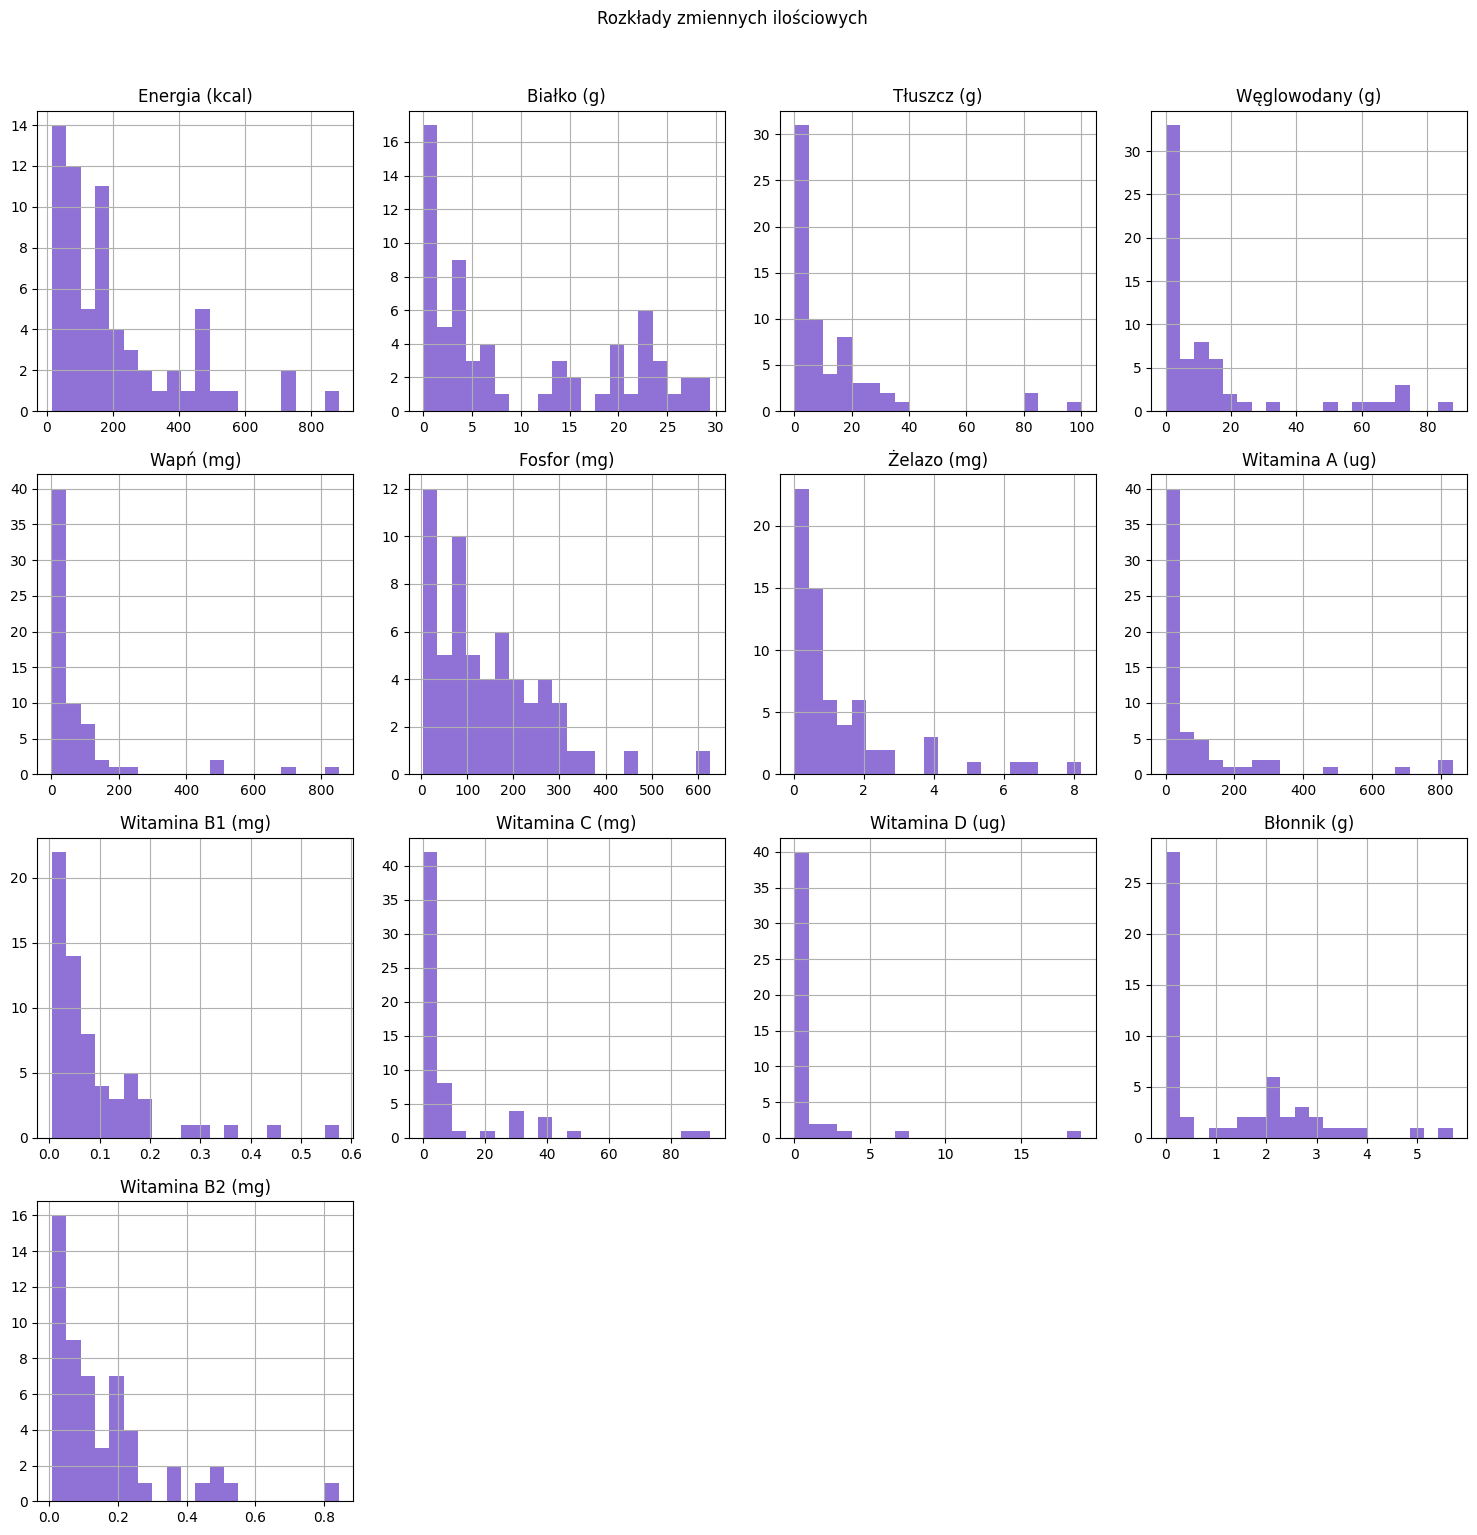

In [21]:
# Histogramy dla zmiennych ilościowych

food_df[predictors].hist(
    bins=20,
    figsize=(15, 15),
    color='#9072d6',
)

plt.suptitle("Rozkłady zmiennych ilościowych", y=1.02)
plt.tight_layout()
plt.show()

In [22]:
def plot_box_strip(df, variables, hue=None):
    """
    Tworzy wykresy pudełkowe z nałożonymi punktami obserwacji dla podanych zmiennych.

    Parametry:
    - df: DataFrame zawierający dane,
    - variables: lista nazw kolumn ze zmiennymi ilościowymi,
    - hue: opcjonalna zmienna grupująca.
    """

    for var in variables:
        plt.figure(figsize=(8, 6))

        sns.boxplot(
            data=df,
            y=var,
            x=hue,
            fliersize=0,
            color='#9072d6'
        )

        sns.stripplot(
            data=df,
            y=var,
            x=hue,
            jitter=0.1,
            alpha=0.3,
            color="black"
        )

        plt.title(f"Wykres pudełkowy z obserwacjami: {var}")
        plt.xlabel(hue if hue else "")
        plt.ylabel(var)
        plt.tight_layout()
        plt.show()

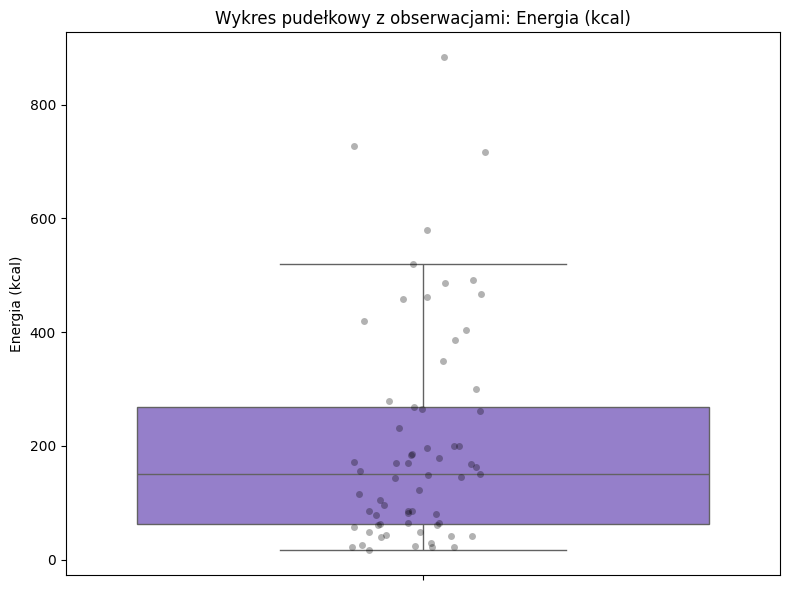

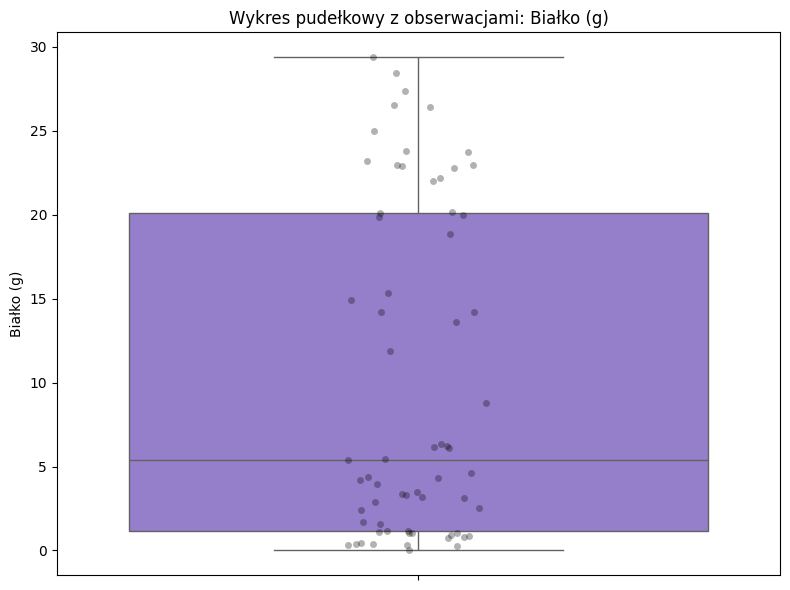

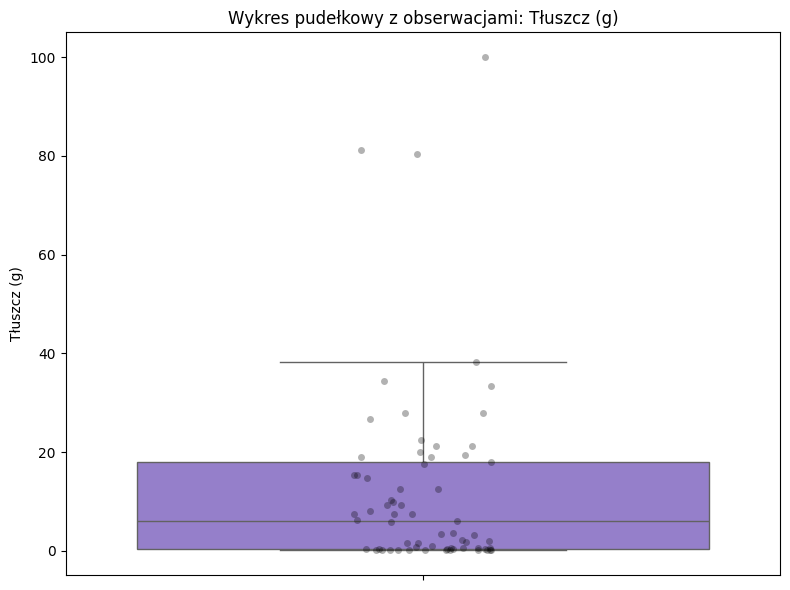

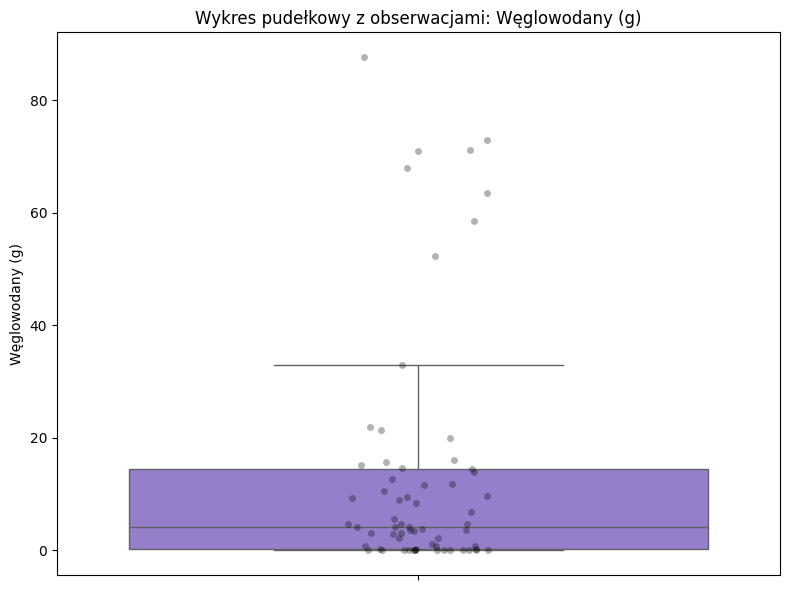

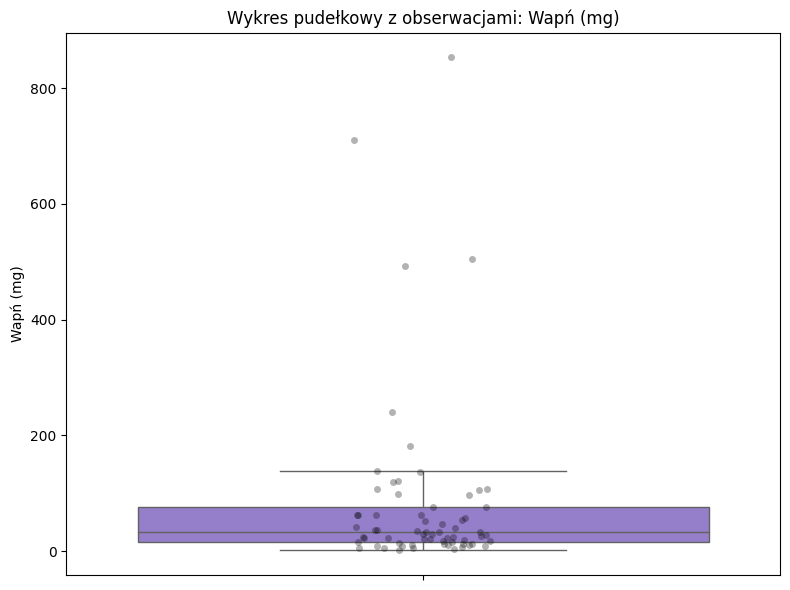

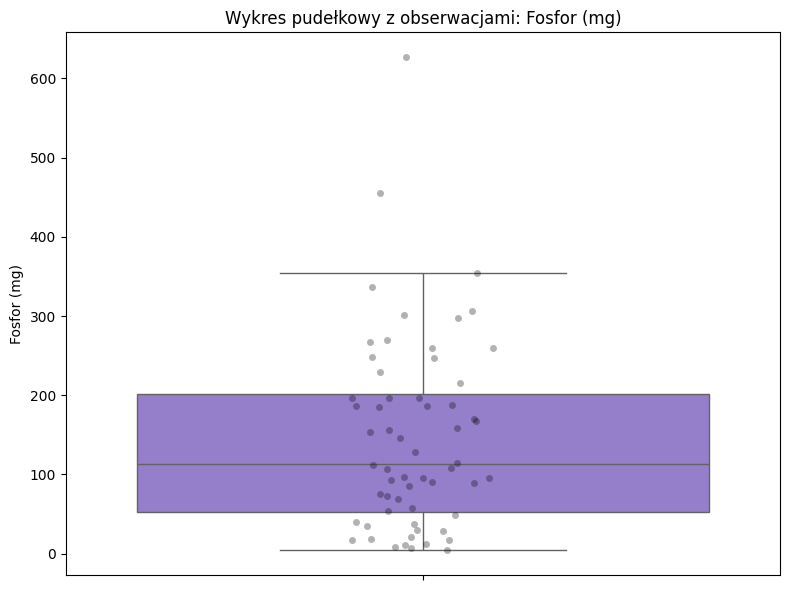

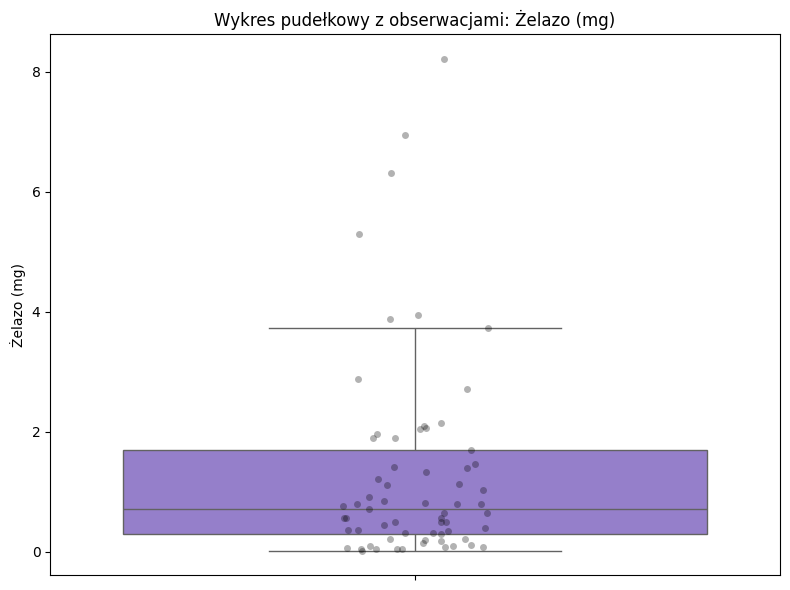

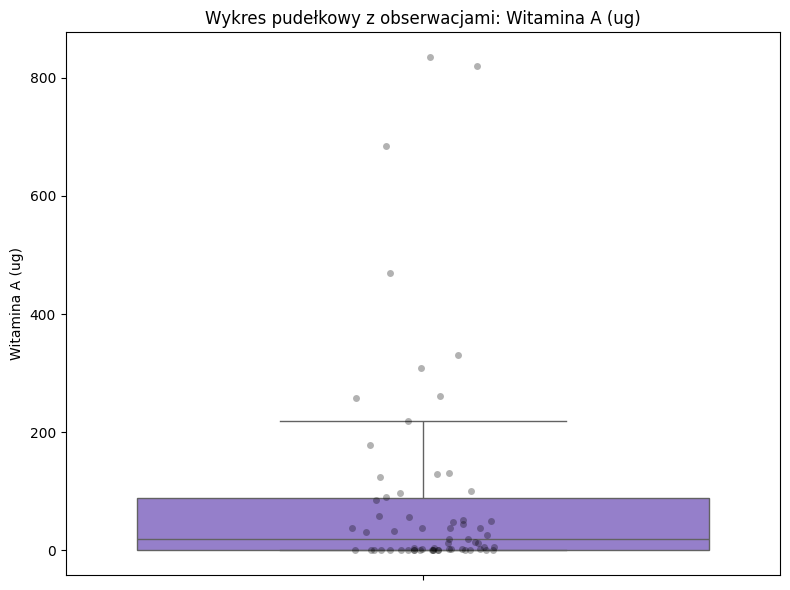

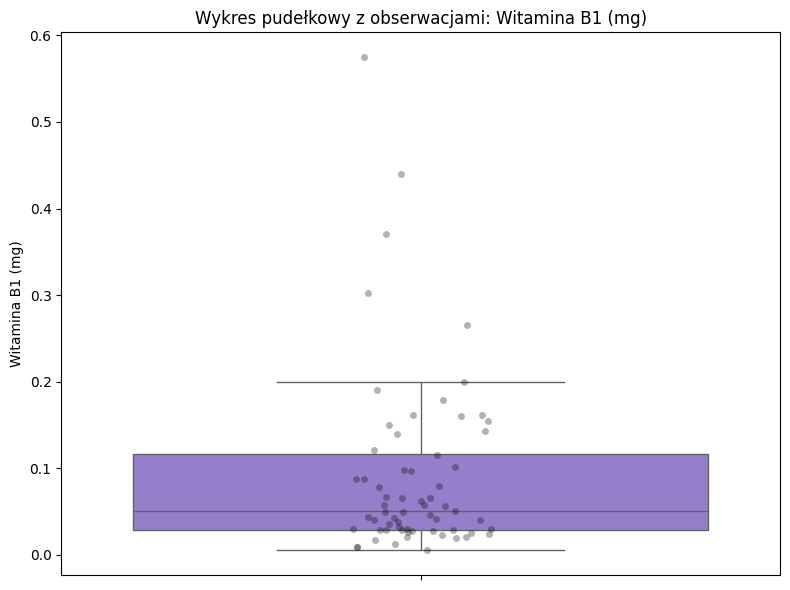

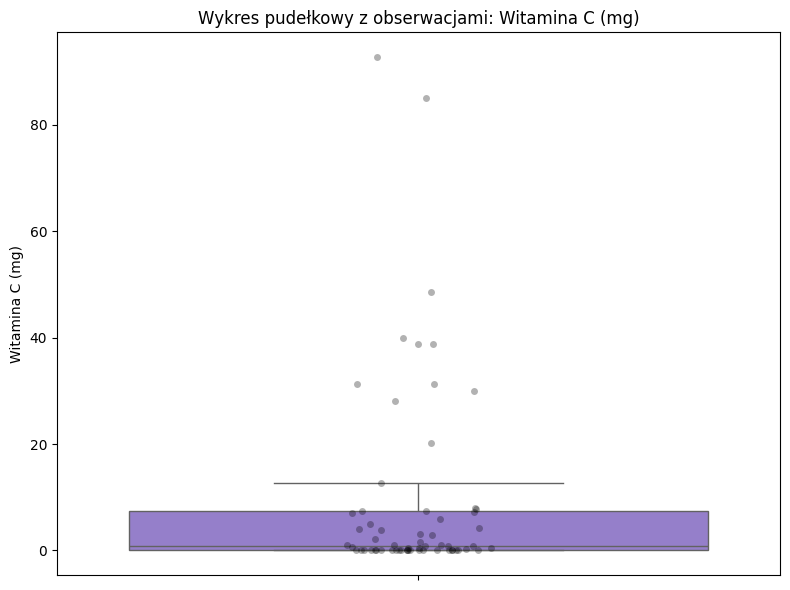

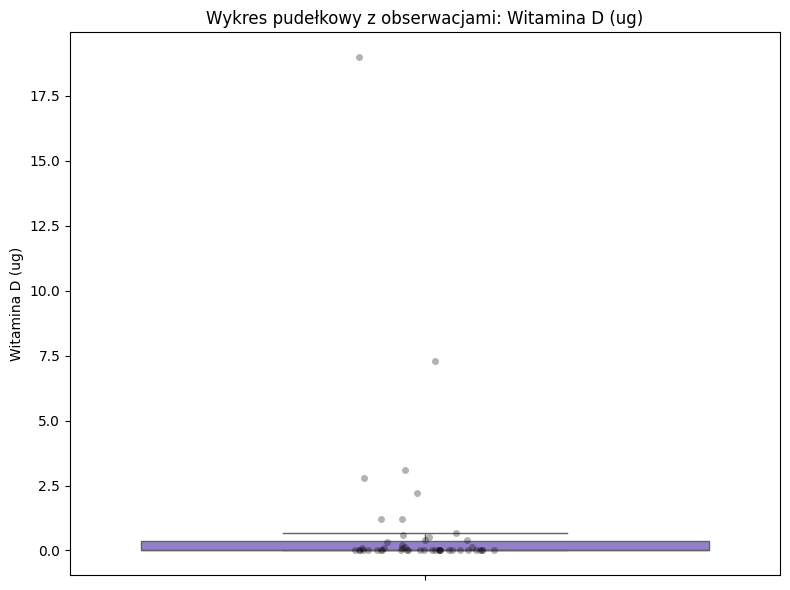

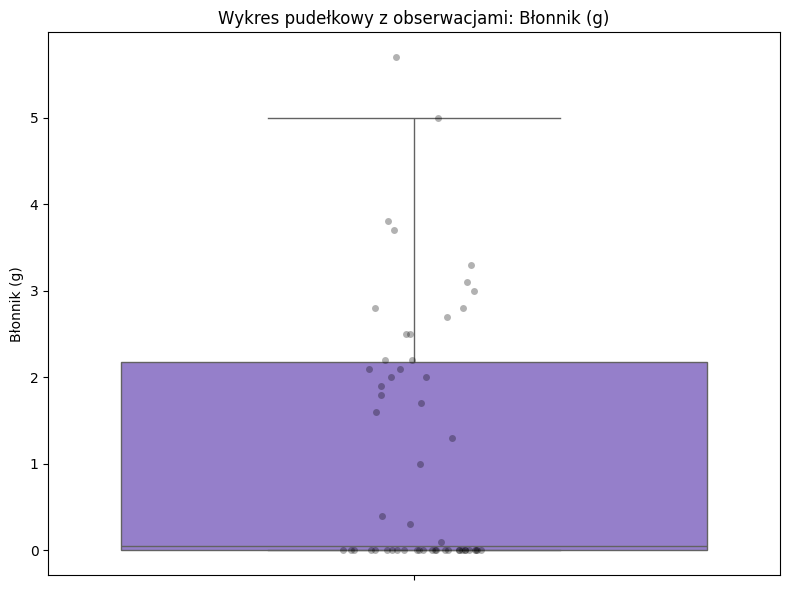

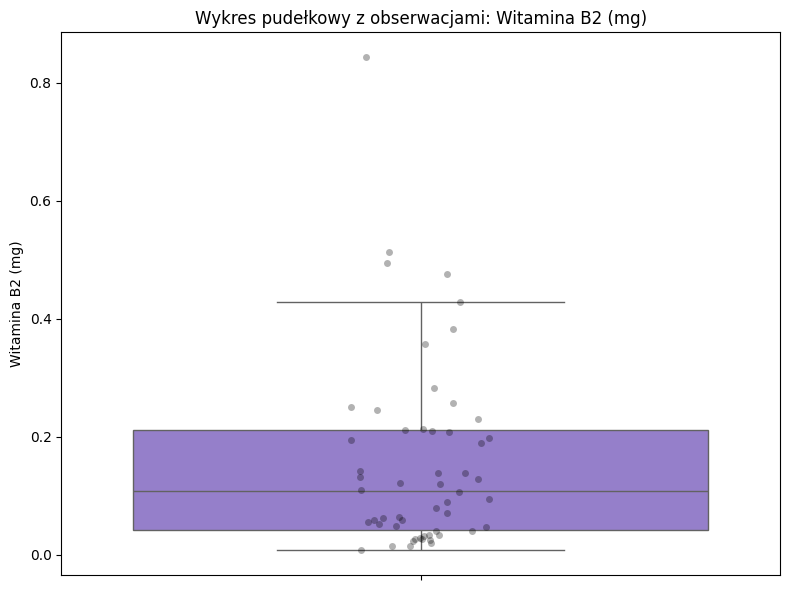

In [23]:
plot_box_strip(food_df, predictors)

Wykresy histogramów i wykresy pudełkowe pomagają ocenić, czy zmienne mają rozkłady symetryczne, skośne lub zawierają wartości nietypowe.

W analizie produktów spożywczych wartości odstające nie muszą oznaczać błędów.  
Produkt o bardzo wysokiej zawartości tłuszczu, błonnika albo określonego mikroelementu może być po prostu specyficznym produktem, a nie błędną obserwacją.

Dlatego wartości odstające należy najpierw zidentyfikować, a dopiero później zdecydować, czy wymagają przycięcia, usunięcia albo pozostawienia w analizie.

## Czyszczenie danych: uzupełnianie braków

Po rozpoznaniu danych przechodzimy do ich przygotowania do analizy skupień.

W tym zbiorze występują braki danych, dlatego musimy zdecydować, jak je uzupełnić.

Przyjmujemy następującą strategię:

- zmienne z niewielkim odsetkiem braków uzupełnimy medianą,
- zmienne z większym odsetkiem braków uzupełnimy metodą KNN.

Warto pamiętać, że wybór metody imputacji jest decyzją analityczną.  
W innych projektach sposób uzupełniania braków powinien zależeć od charakteru danych, skali zmiennych oraz celu analizy.

In [24]:
# Uzupełnianie braków danych

# Dla zmiennych z niewielkim odsetkiem braków stosujemy medianę
if len(missing_below_5) > 0:
    simple_imputer = SimpleImputer(strategy="median")
    food_df.loc[:, missing_below_5] = simple_imputer.fit_transform(
        food_df[missing_below_5]
    )

# Dla pozostałych braków stosujemy imputację KNN
# Uwaga: KNN opiera się na odległościach, więc w bardziej rygorystycznej analizie
# warto rozważyć wcześniejsze przeskalowanie zmiennych.

knn_imputer = KNNImputer(
    n_neighbors=3,
    weights="distance"
)

food_df.loc[:, predictors] = knn_imputer.fit_transform(food_df[predictors])

# Sprawdzenie, czy braki zostały uzupełnione

null_report_after_imputation = food_df[predictors].isnull().mean().sort_values(
    ascending=False
)

null_report_after_imputation

Energia (kcal)      0.0
Białko (g)          0.0
Tłuszcz (g)         0.0
Węglowodany (g)     0.0
Wapń (mg)           0.0
Fosfor (mg)         0.0
Żelazo (mg)         0.0
Witamina A (ug)     0.0
Witamina B1 (mg)    0.0
Witamina C (mg)     0.0
Witamina D (ug)     0.0
Błonnik (g)         0.0
Witamina B2 (mg)    0.0
dtype: float64

> **Uwaga metodyczna**
>
> Imputacja KNN opiera się na podobieństwie obserwacji, które jest wyznaczane na podstawie odległości między nimi.
>
> Oznacza to, że zmienne o większych wartościach lub szerszym zakresie mogą mieć silniejszy wpływ na wynik uzupełniania braków danych.
>
> W tym przykładzie pozostawiamy procedurę w uproszczonej formie, ale w bardziej rygorystycznej analizie warto rozważyć przeskalowanie zmiennych przed zastosowaniem imputacji KNN.

## Czyszczenie danych: wartości odstające

Kolejnym krokiem jest ocena wartości odstających.

Wartości odstające nie zawsze są błędami. W przypadku produktów spożywczych mogą oznaczać produkty rzeczywiście nietypowe, np. bardzo tłuste, bardzo bogate w białko albo zawierające wyjątkowo dużo wybranego składnika.

W tym przykładzie zastosujemy winsoryzację, czyli przycięcie wartości skrajnych do granic wyznaczonych metodą IQR.  
Traktujemy to jako jedną z możliwych metod ograniczania wpływu wartości ekstremalnych na analizę skupień.

In [25]:
# Zachowujemy kopię danych przed winsoryzacją

food_df_before_winsorization = food_df.copy()

# capping_method='iqr' - metoda oparta na rozstępie kwartylowym
# fold=1.5 - parametr sterujący szerokością granic przycinania
# tail='both' - przycinanie wartości odstających z obu stron rozkładu

winsorizer = Winsorizer(
    capping_method="iqr",
    fold=1.5,
    tail="both"
)

food_df.loc[:, predictors] = winsorizer.fit_transform(food_df[predictors])

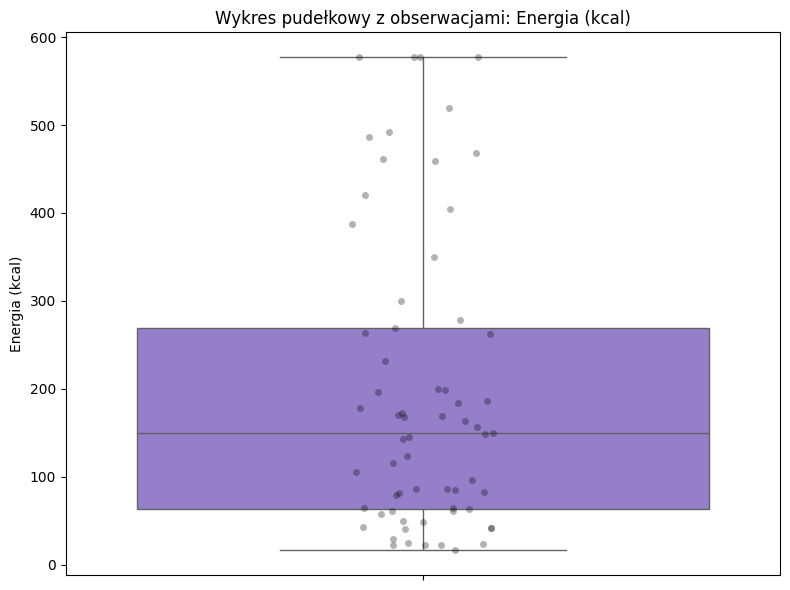

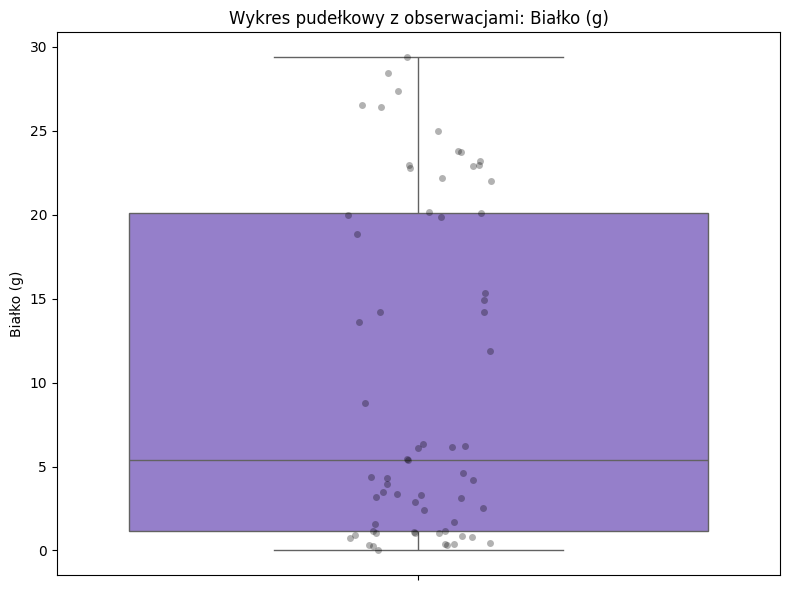

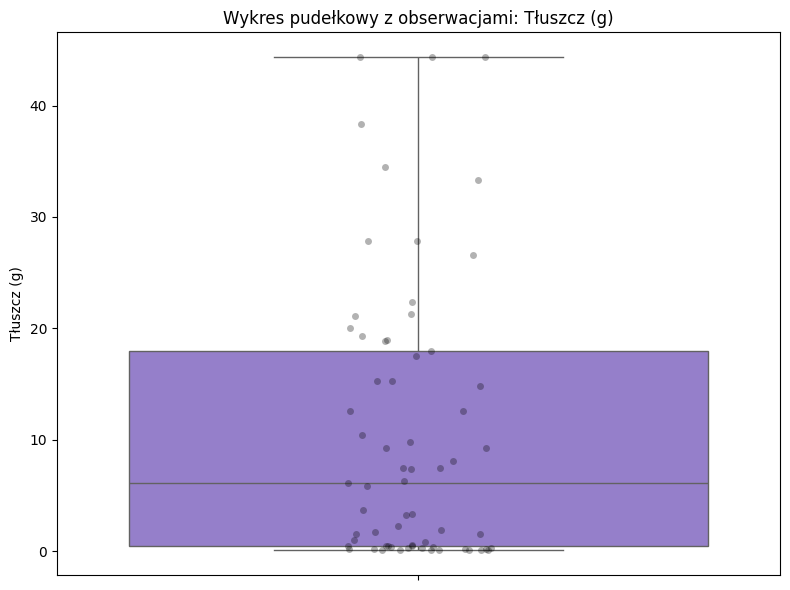

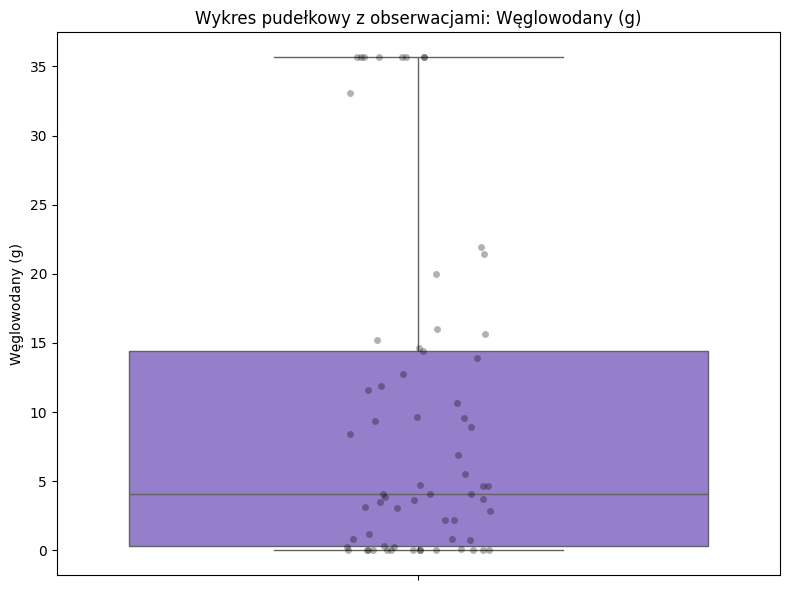

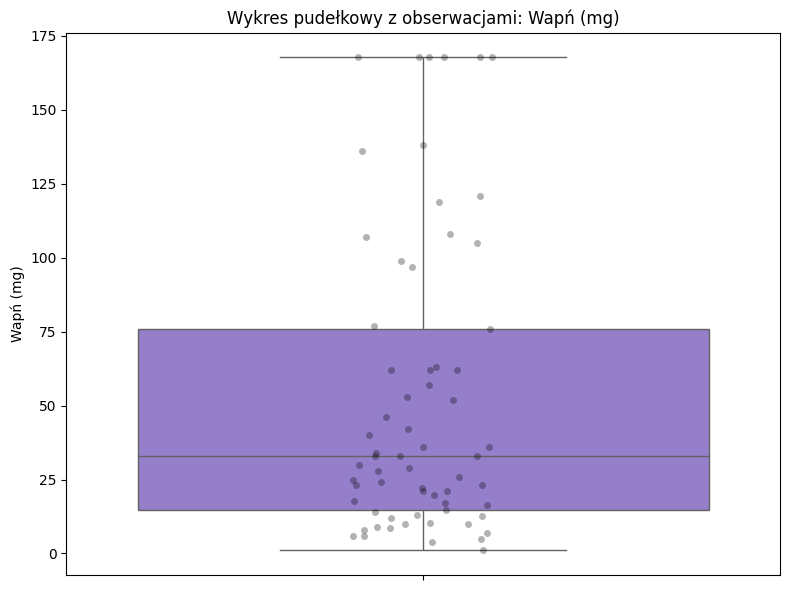

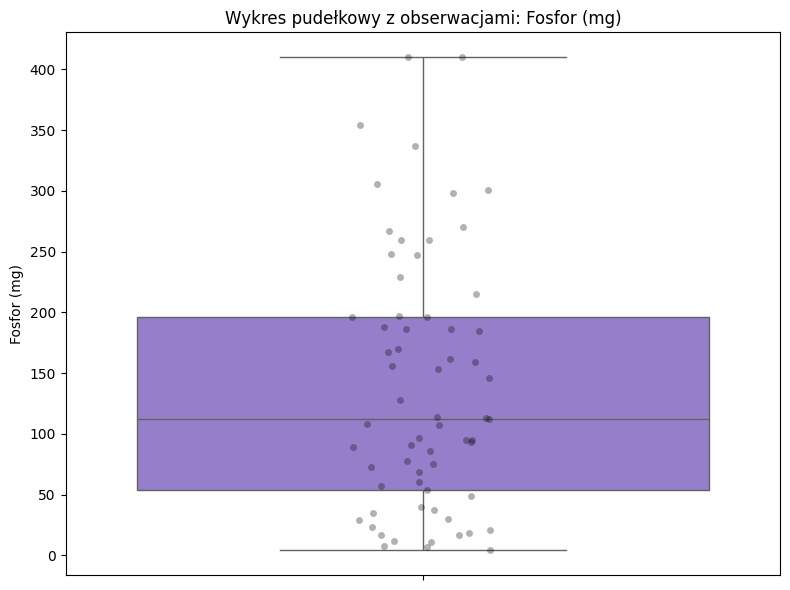

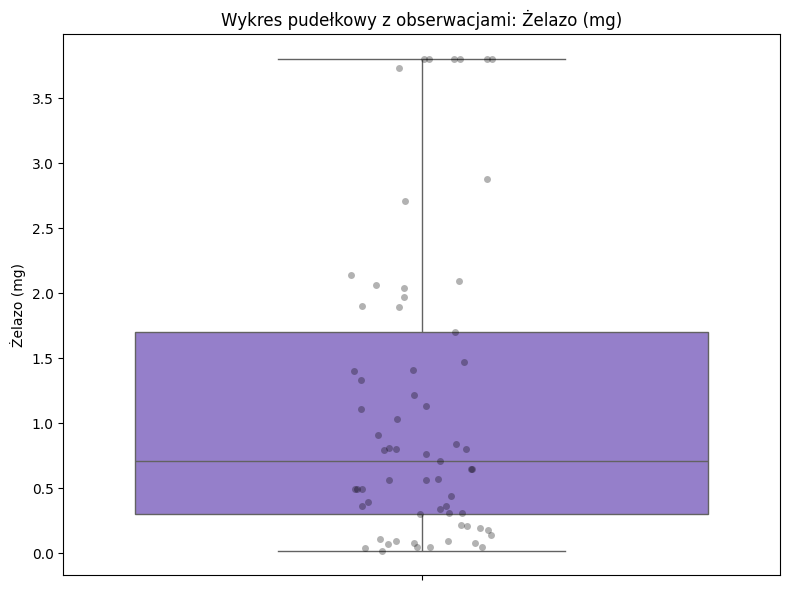

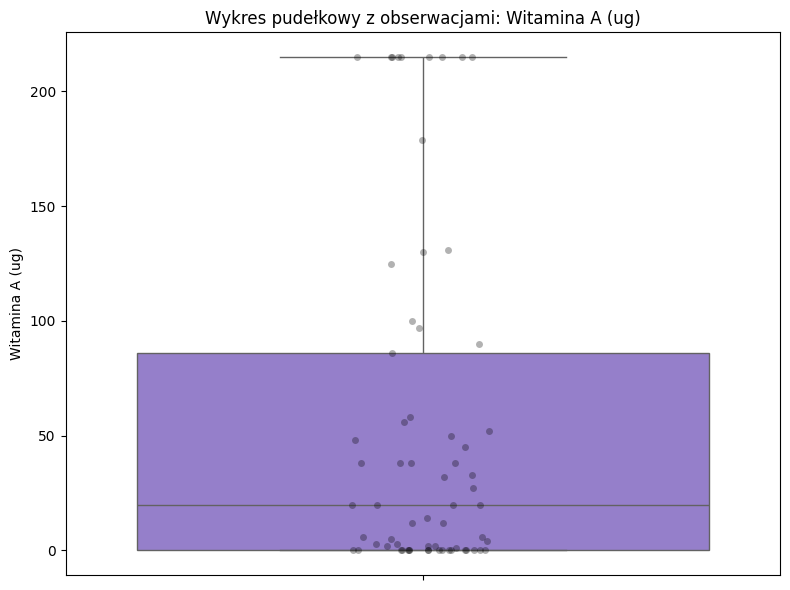

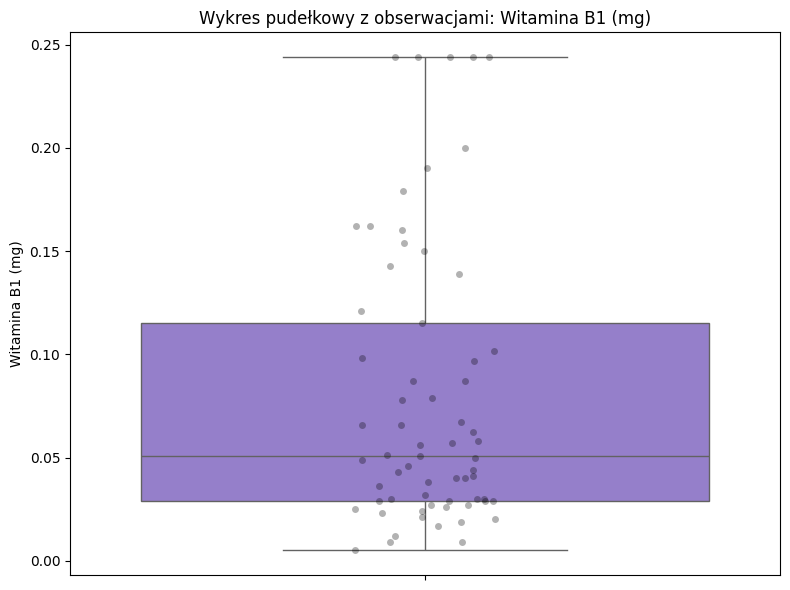

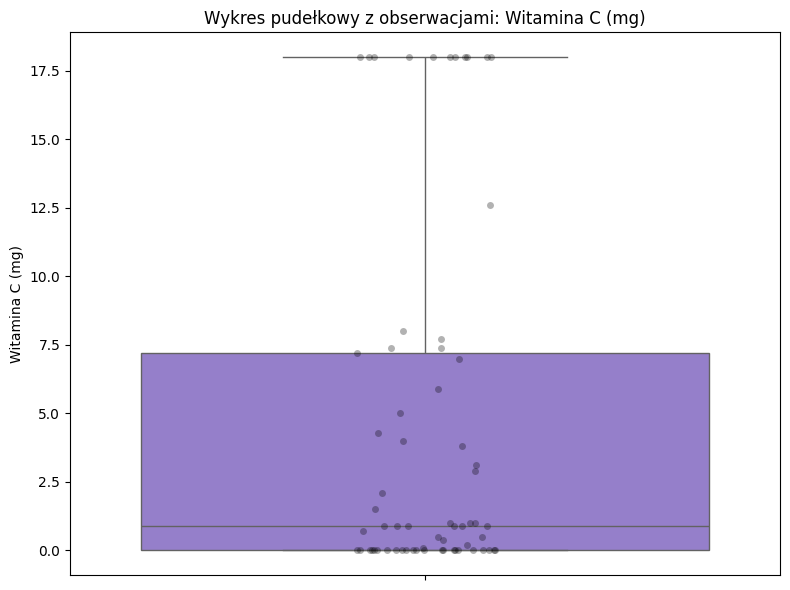

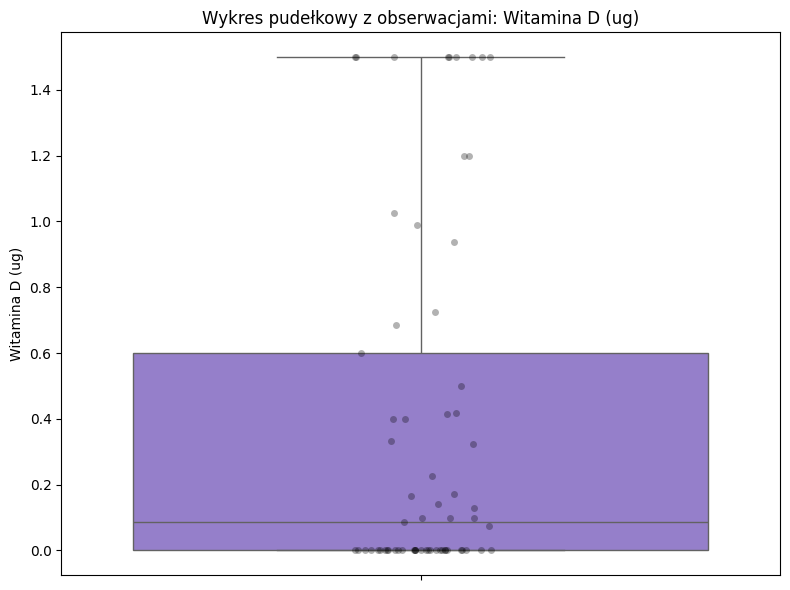

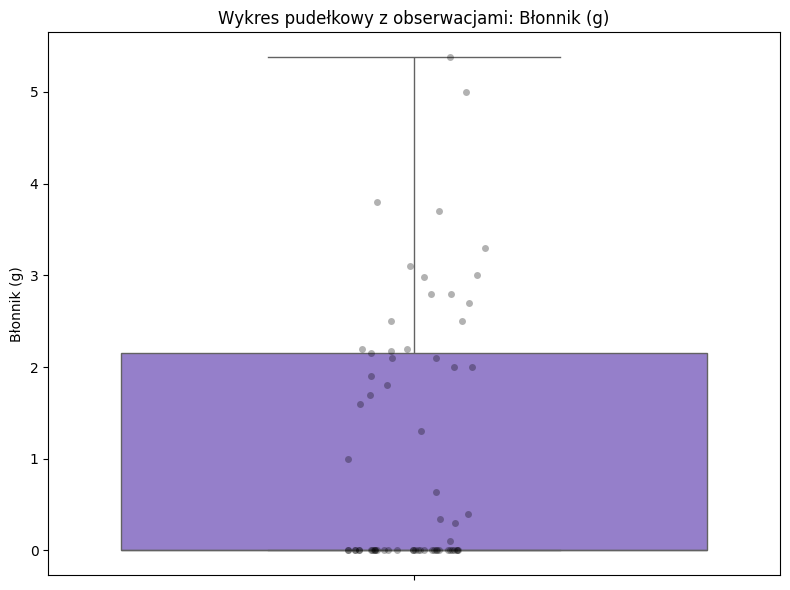

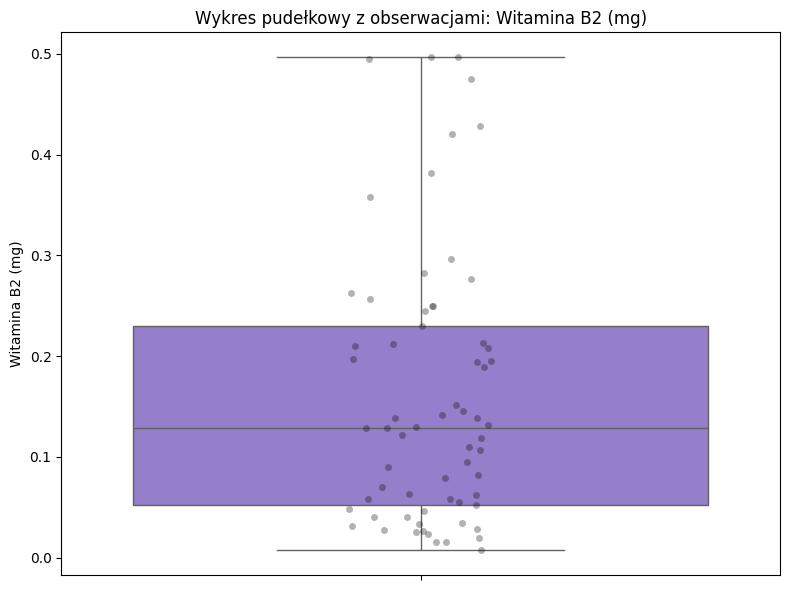

In [26]:
# Sprawdzenie efektu winsoryzacji
plot_box_strip(food_df, predictors)

## Powiązania pomiędzy zmiennymi

Przed skalowaniem i modelowaniem warto sprawdzić zależności pomiędzy zmiennymi.

Silnie skorelowane zmienne mogą wnosić podobną informację do modelu.  
Nie oznacza to automatycznie, że którąś z nich trzeba usunąć, ale może być podstawą do rozważenia uproszczenia zestawu zmiennych.

W tym celu obliczymy korelacje Spearmana i przedstawimy je na mapie ciepła.

In [27]:
# Obliczanie macierzy korelacji rang Spearmana

spearman_corr_matrix = food_df[predictors].corr(method="spearman")

spearman_corr_matrix

,Energia (kcal),Białko (g),Tłuszcz (g),Węglowodany (g),Wapń (mg),Fosfor (mg),Żelazo (mg),Witamina A (ug),Witamina B1 (mg),Witamina C (mg),Witamina D (ug),Błonnik (g),Witamina B2 (mg)
Energia (kcal),1.000000,0.368840,0.915020,0.000373,0.173933,0.558738,0.188796,0.086258,-0.071329,-0.735078,0.307367,-0.347880,0.410785
Białko (g),0.368840,1.000000,0.383197,-0.499357,0.197153,0.866297,0.518662,0.020996,0.282332,-0.440510,0.691088,-0.548094,0.727771
Tłuszcz (g),0.915020,0.383197,1.000000,-0.136946,0.309192,0.583465,0.157732,0.237116,-0.073172,-0.745210,0.377403,-0.411671,0.505300
Węglowodany (g),0.000373,-0.499357,-0.136946,1.000000,0.262279,-0.522945,-0.122021,-0.035821,-0.119997,0.309969,-0.684078,0.647069,-0.363161
Wapń (mg),0.173933,0.197153,0.309192,0.262279,1.000000,0.233798,0.057907,0.623478,0.000252,0.009130,0.108199,0.028285,0.264030
Fosfor (mg),0.558738,0.866297,0.583465,-0.522945,0.233798,1.000000,0.393939,0.135884,0.188310,-0.543722,0.709349,-0.649446,0.724470
Żelazo (mg),0.188796,0.518662,0.157732,-0.122021,0.057907,0.393939,1.000000,-0.149633,0.554648,-0.069697,0.123532,0.022961,0.460012
Witamina A (ug),0.086258,0.020996,0.237116,-0.035821,0.623478,0.135884,-0.149633,1.000000,-0.180226,0.053398,0.327542,-0.095391,0.147446
Witamina B1 (mg),-0.071329,0.282332,-0.073172,-0.119997,0.000252,0.188310,0.554648,-0.180226,1.000000,0.154910,-0.076594,0.062860,0.358586
Witamina C (mg),-0.735078,-0.440510,-0.745210,0.309969,0.009130,-0.543722,-0.069697,0.053398,0.154910,1.000000,-0.473471,0.569228,-0.464166


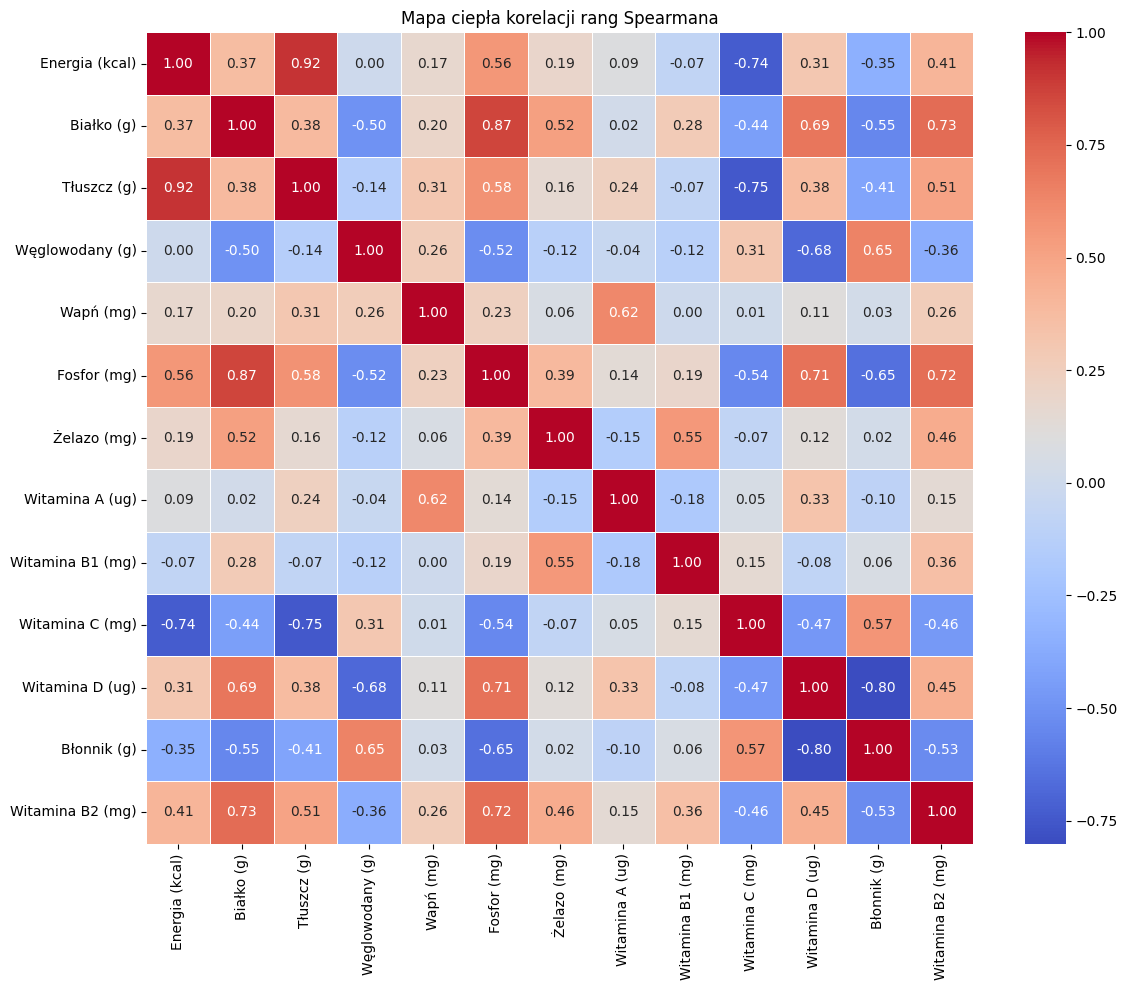

In [28]:
# Mapa ciepła korelacji

plt.figure(figsize=(12, 10))

sns.heatmap(
    spearman_corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Mapa ciepła korelacji rang Spearmana")
plt.tight_layout()
plt.show()

Zmienne `Tłuszcz (g)` oraz `Energia (kcal)` są silnie powiązane.

Możemy rozważyć usunięcie jednej z nich, aby ograniczyć powielanie podobnej informacji w analizie.  
W tym przykładzie usuniemy zmienną `Energia (kcal)`, ponieważ jest ona w dużej mierze pochodną składu odżywczego produktu.

In [29]:
# Usunięcie zmiennej Energia (kcal) z listy predyktorów

predictors = [var for var in predictors if var != "Energia (kcal)"]

print(predictors)

['Białko (g)', 'Tłuszcz (g)', 'Węglowodany (g)', 'Wapń (mg)', 'Fosfor (mg)', 'Żelazo (mg)', 'Witamina A (ug)', 'Witamina B1 (mg)', 'Witamina C (mg)', 'Witamina D (ug)', 'Błonnik (g)', 'Witamina B2 (mg)']


In [30]:
def scatter_plot(df, variables, hue=None):
    """
    Tworzy wykres rozrzutu dla dwóch podanych zmiennych.

    Parametry:
    - df: DataFrame z danymi,
    - variables: lista dokładnie 2 nazw kolumn [x, y],
    - hue: opcjonalna zmienna jakościowa do kolorowania punktów.
    """

    if len(variables) != 2:
        raise ValueError("Lista 'variables' musi zawierać dokładnie 2 zmienne.")

    x, y = variables

    plt.figure(figsize=(8, 6))

    if hue:
        sns.scatterplot(data=df, x=x, y=y, hue=hue, palette="Set1", alpha=0.7)
        plt.legend(title=hue)
    else:
        sns.scatterplot(data=df, x=x, y=y, alpha=0.7)

    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"Wykres rozrzutu: {x} vs {y}")
    plt.tight_layout()
    plt.show()

In [31]:
print(predictors)

['Białko (g)', 'Tłuszcz (g)', 'Węglowodany (g)', 'Wapń (mg)', 'Fosfor (mg)', 'Żelazo (mg)', 'Witamina A (ug)', 'Witamina B1 (mg)', 'Witamina C (mg)', 'Witamina D (ug)', 'Błonnik (g)', 'Witamina B2 (mg)']


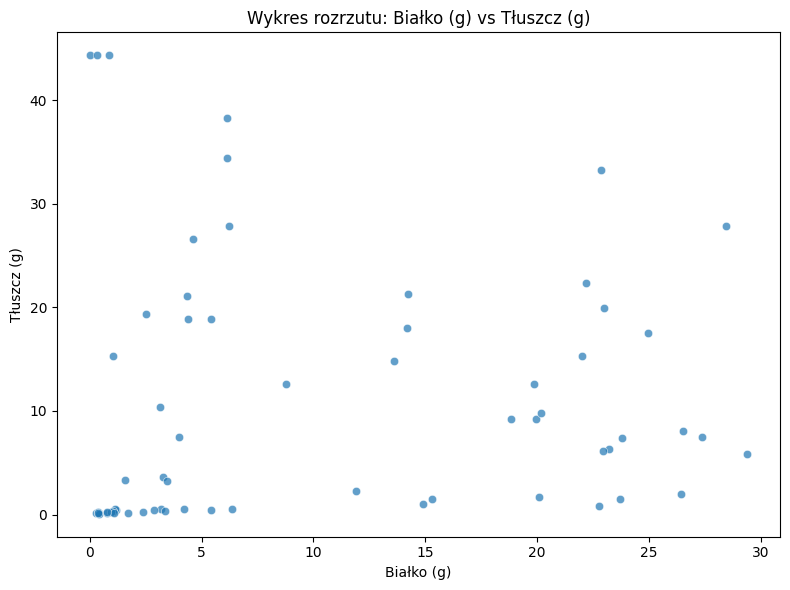

In [32]:
scatter_plot(food_df, ["Białko (g)", "Tłuszcz (g)"])

## Skalowanie danych

Algorytmy analizy skupień często wykorzystują odległości między obserwacjami.

Jeżeli zmienne mają różne skale, zmienne o większych wartościach mogą silniej wpływać na wynik grupowania.  
Dlatego przed modelowaniem przeskalujemy dane do wspólnego zakresu.

W tym przykładzie użyjemy `MinMaxScaler`, który przekształca wartości zmiennych do przedziału od 0 do 1.

In [33]:
# Skalowanie wartości predyktorów
# Przed wykonaniem skalowania tworzymy kopię ramki danych

scaled_food_df = food_df.copy()

min_max_scaler = MinMaxScaler()

scaled_food_df.loc[:, predictors] = min_max_scaler.fit_transform(
    scaled_food_df[predictors]
)

scaled_food_df[predictors].head()

,Białko (g),Tłuszcz (g),Węglowodany (g),Wapń (mg),Fosfor (mg),Żelazo (mg),Witamina A (ug),Witamina B1 (mg),Witamina C (mg),Witamina D (ug),Błonnik (g),Witamina B2 (mg)
Butter,0.028925,1.000000,0.001682,0.137961,0.267918,0.000000,1.000000,0.000000,0.0,0.659891,0.0,0.055102
"Cheese, cheddar",0.778244,0.750593,0.086616,1.000000,1.000000,0.031746,1.000000,0.100418,0.0,0.400000,0.0,0.859184
"Cheese, cream",0.209279,0.776109,0.154731,0.575835,0.253538,0.023810,1.000000,0.075314,0.0,1.000000,0.0,0.455102
"Cheese, feta",0.483553,0.478943,0.114647,1.000000,0.819692,0.166667,0.581395,0.623431,0.0,0.266667,0.0,1.000000
Mozzarella,0.754424,0.503105,0.061388,1.000000,0.861538,0.111111,0.832558,0.104603,0.0,0.266667,0.0,0.563265


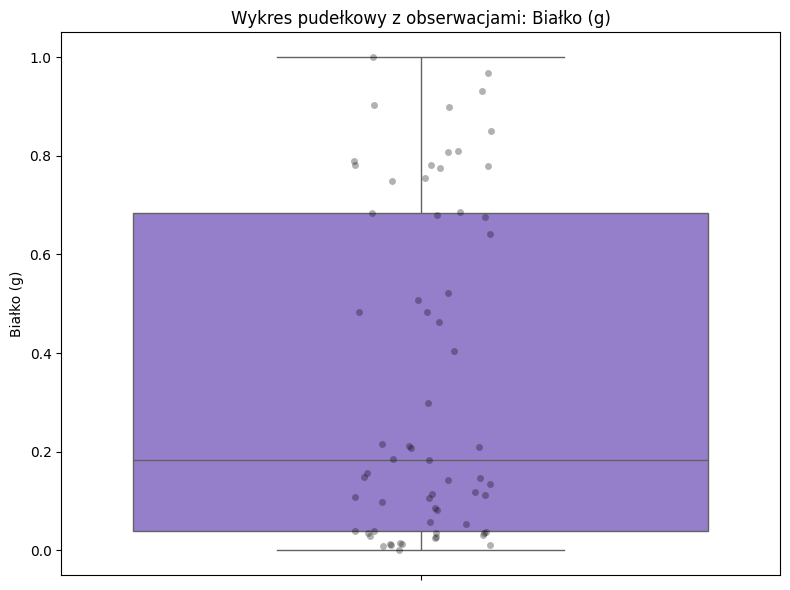

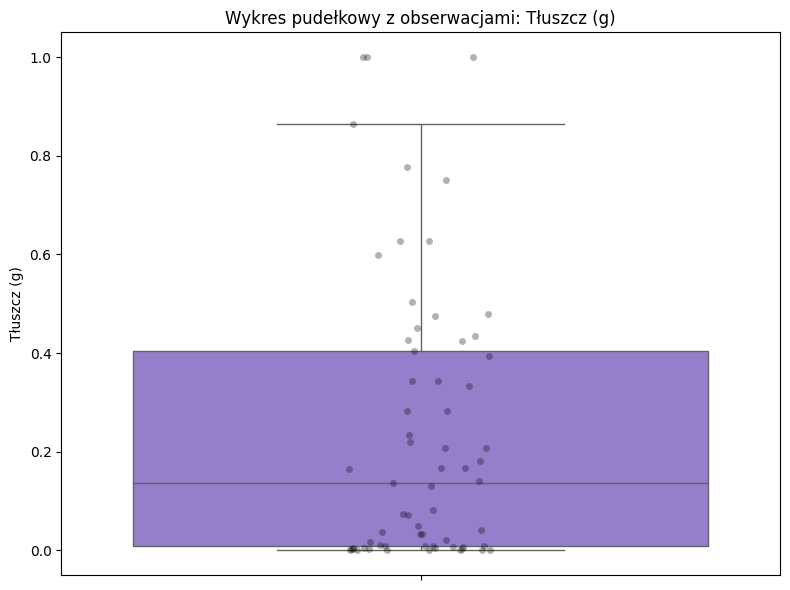

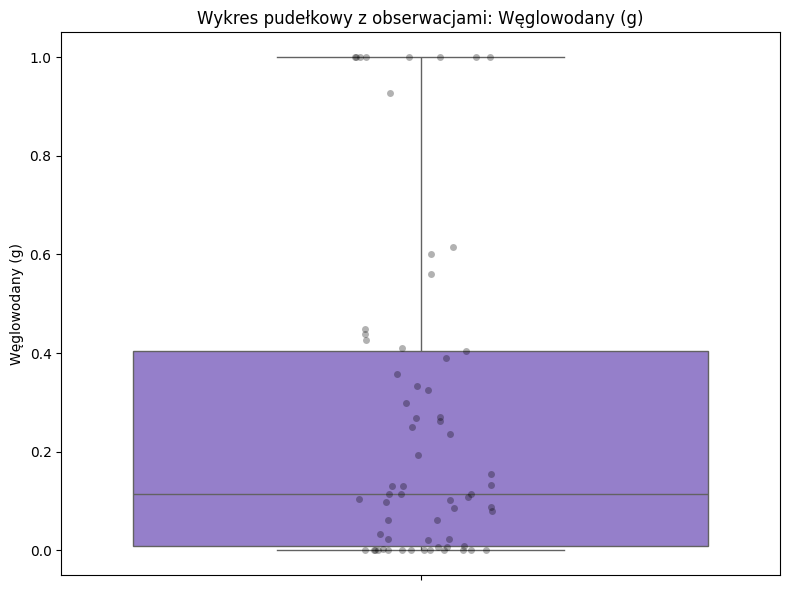

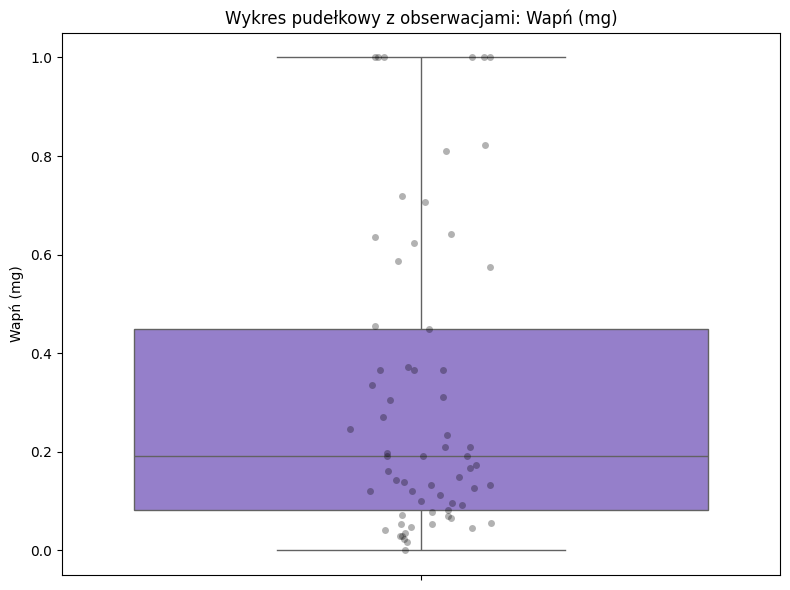

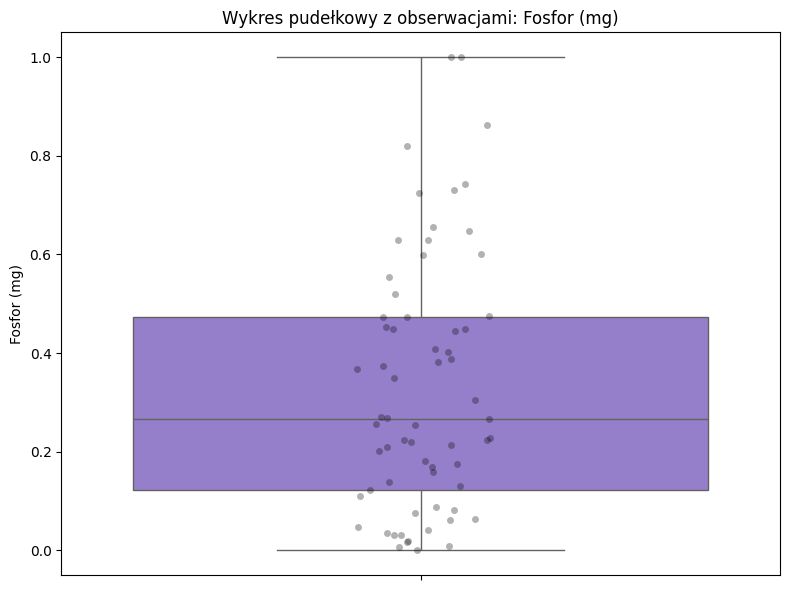

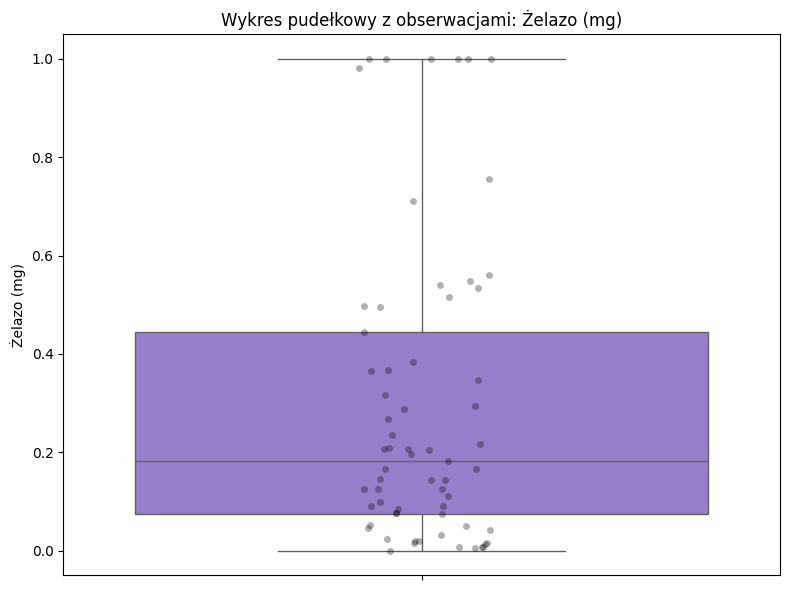

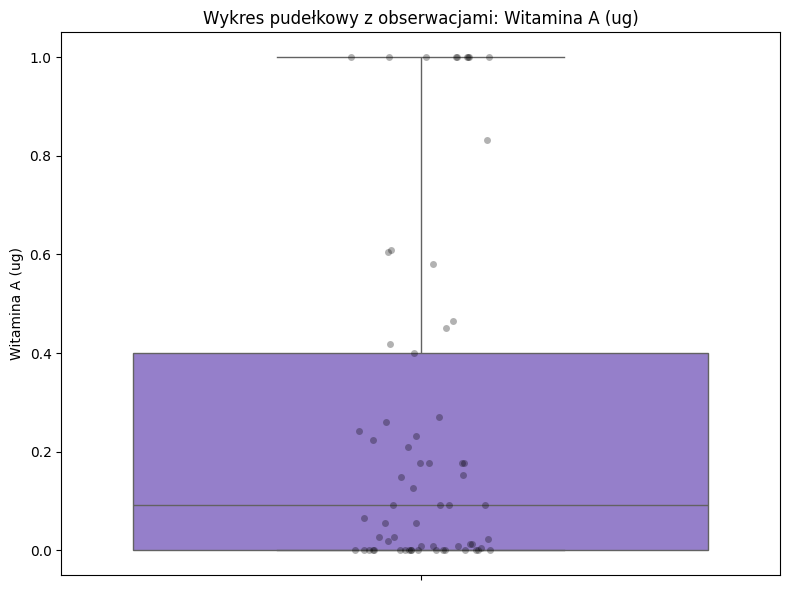

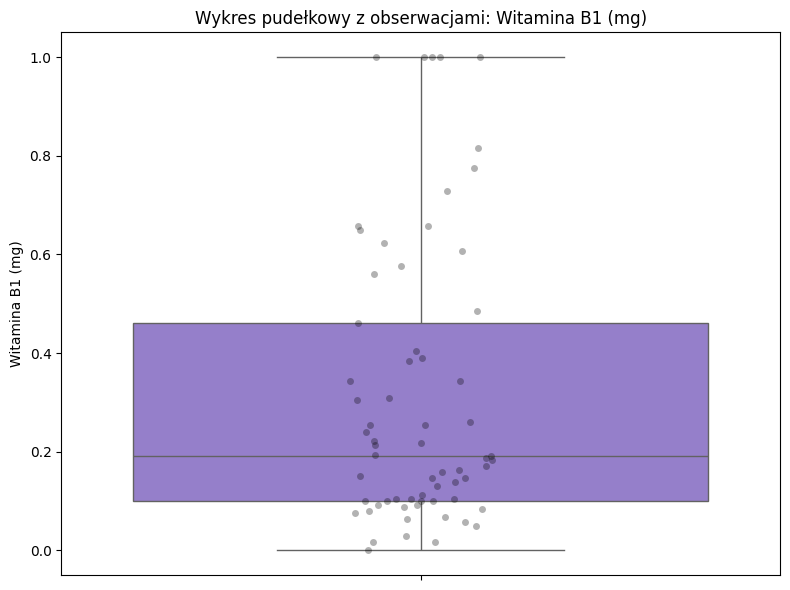

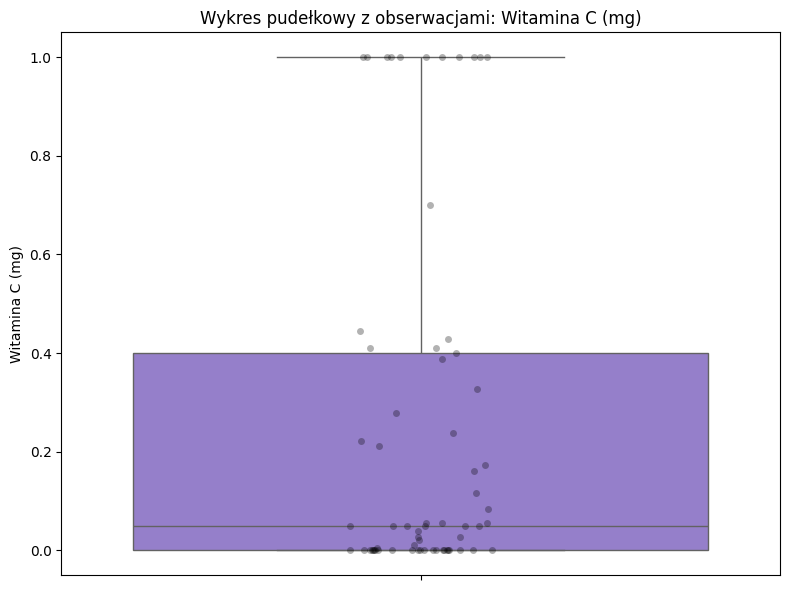

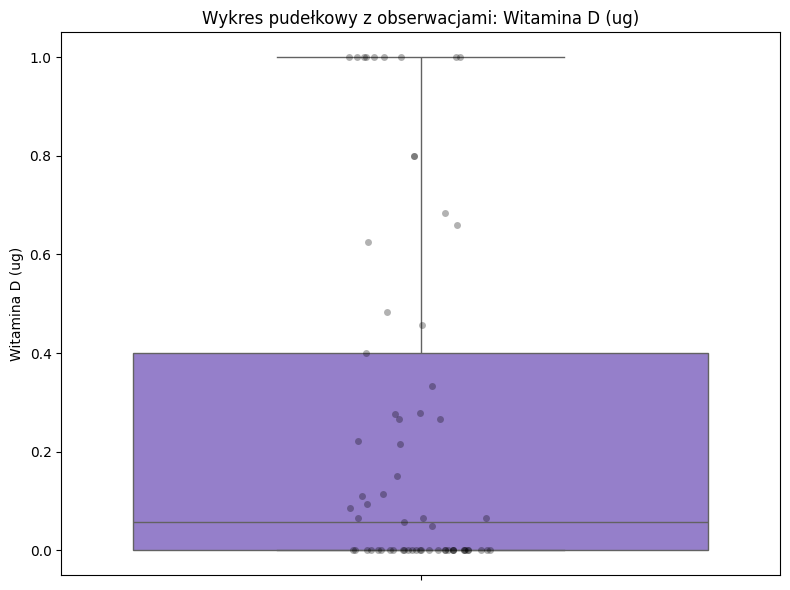

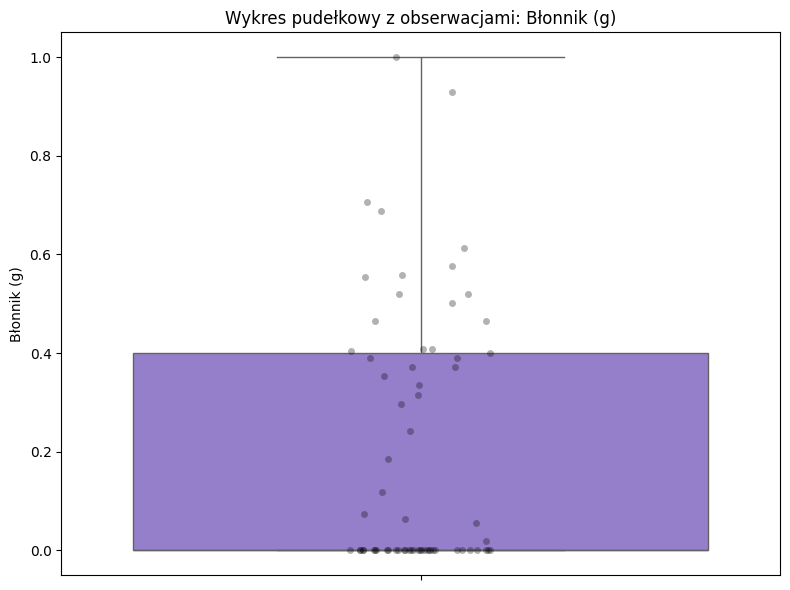

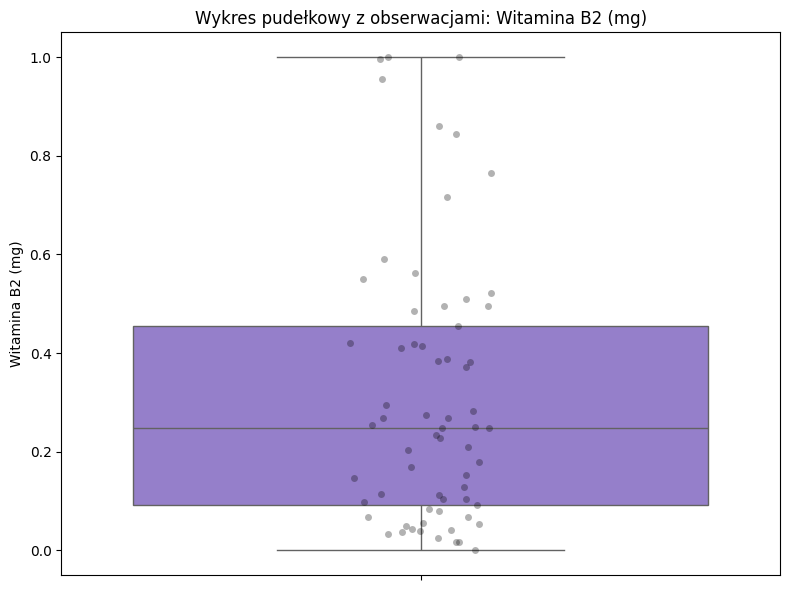

In [34]:
# Sprawdzenie rozkładów zmiennych po skalowaniu
plot_box_strip(scaled_food_df, predictors)

# Zadanie 3 -  Samodzielna analiza skupień produktów spożywczych

Dane zostały przygotowane do analizy skupień.

Na podstawie przygotowanych ramek:

- `food_df`,
- `scaled_food_df`,
- `predictors`

wykonaj samodzielną analizę skupień produktów spożywczych.

Wykorzystaj notebook ze zbiorem Iris jako wzorzec postępowania.

## Co należy zrobić?

1. Dobierz liczbę skupień, korzystając z co najmniej dwóch kryteriów, np.:
   - wykresu osypiska,
   - wskaźnika sylwetki,
   - Calinski-Harabasz Score,
   - Davies-Bouldin Score.

2. Zbuduj model analizy skupień wybraną metodą, np. KMeans lub metodą aglomeracyjną.

3. Oceń jakość otrzymanego podziału:
   - sprawdź liczności skupień,
   - oblicz wybrane miary jakości,
   - przygotuj wizualizację skupień za pomocą PCA lub t-SNE.

4. Zinterpretuj otrzymane skupienia:
   - czym różnią się grupy produktów,
   - które zmienne najlepiej opisują poszczególne skupienia,
   - jak można nazwać otrzymane grupy.

## Efekt końcowy

Przygotuj krótkie podsumowanie analizy, w którym wskażesz:

- wybraną metodę,
- wybraną liczbę skupień,
- najważniejsze wyniki oceny jakości,
- interpretację otrzymanych grup produktów.

### K-means - dobór liczby skupień

In [35]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# Zakres liczby skupień
cluster_range = range(2, 16)

# Listy do zapisania wyników
inertia_values = []
silhouette_values = []
calinski_harabasz_values = []
davies_bouldin_values = []

# Pętla dla różnych wartości k
for k in cluster_range:
    model = KMeans(
        n_clusters=k,
        random_state=seed,
        n_init=10
    )
    
    labels = model.fit_predict(scaled_food_df[predictors])
    
    inertia_values.append(model.inertia_)
    silhouette_values.append(
        silhouette_score(scaled_food_df[predictors], labels)
    )
    calinski_harabasz_values.append(
        calinski_harabasz_score(scaled_food_df[predictors], labels)
    )
    davies_bouldin_values.append(
        davies_bouldin_score(scaled_food_df[predictors], labels)
    )

# Zestawienie wyników w jednej tabeli
clustering_metrics = pd.DataFrame({
    "Liczba skupień": list(cluster_range),
    "Inercja": inertia_values,
    "Wskaźnik sylwetki": silhouette_values,
    "Calinski-Harabasz": calinski_harabasz_values,
    "Davies-Bouldin": davies_bouldin_values
})

clustering_metrics.round(3)

,Liczba skupień,Inercja,Wskaźnik sylwetki,Calinski-Harabasz,Davies-Bouldin
0,2,53.373,0.273,25.905,1.509
1,3,44.207,0.286,21.818,1.324
2,4,36.442,0.275,21.692,1.372
3,5,32.640,0.255,19.613,1.340
4,6,29.410,0.252,18.420,1.392
5,7,24.931,0.279,19.537,1.230
6,8,23.713,0.259,17.721,1.139
7,9,20.788,0.295,18.363,1.090
8,10,18.604,0.306,18.631,1.039
9,11,17.682,0.311,17.602,1.035


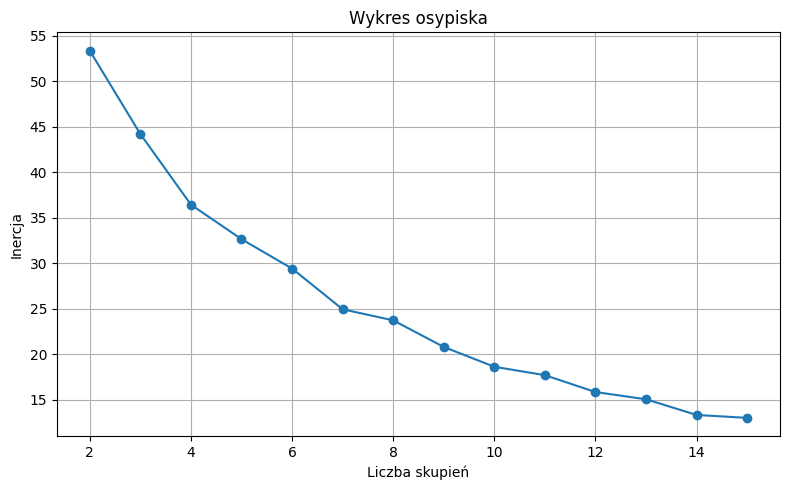

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(
    clustering_metrics["Liczba skupień"],
    clustering_metrics["Inercja"],
    marker="o",
    linestyle="-"
)

plt.xlabel("Liczba skupień")
plt.ylabel("Inercja")
plt.title("Wykres osypiska")
plt.grid(True)
plt.tight_layout()
plt.show()

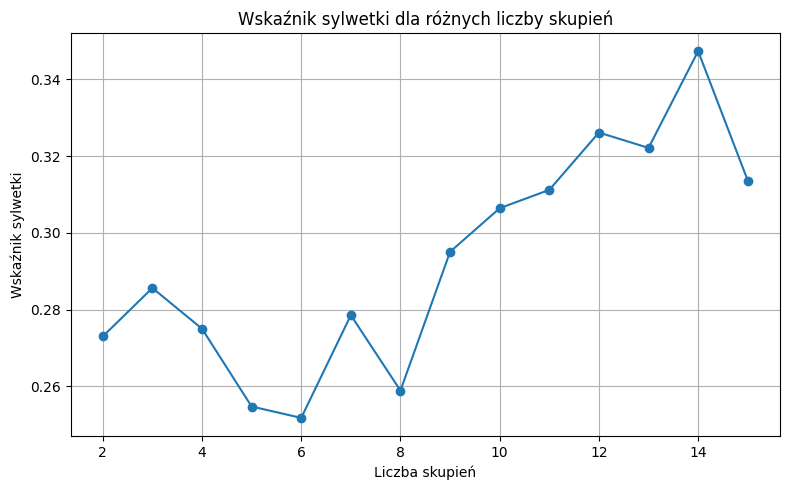

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(
    clustering_metrics["Liczba skupień"],
    clustering_metrics["Wskaźnik sylwetki"],
    marker="o",
    linestyle="-"
)

plt.xlabel("Liczba skupień")
plt.ylabel("Wskaźnik sylwetki")
plt.title("Wskaźnik sylwetki dla różnych liczby skupień")
plt.grid(True)
plt.tight_layout()
plt.show()

### Ostateczny model - 4 skupienia

In [38]:
n_clusters = 4

# Budowa modelu KMeans
kmeans_model = KMeans(
    n_clusters=n_clusters,
    random_state=seed,
    n_init=10
)
kmeans_model_classes = kmeans_model.fit_predict(scaled_food_df[predictors])

food_df['predicted_class'] = kmeans_model_classes
scaled_food_df['predicted_class'] = kmeans_model_classes

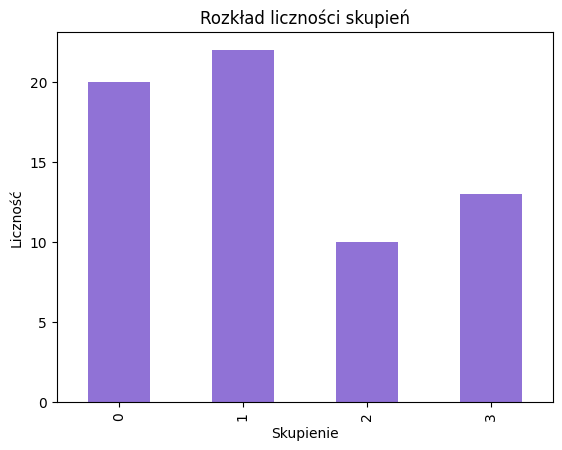

In [39]:
food_df["predicted_class"].value_counts().sort_index().plot(kind="bar", color = "#9072d6")

plt.xlabel("Skupienie")
plt.ylabel("Liczność")
plt.title("Rozkład liczności skupień")

plt.show()

### metryki:

In [40]:
# wzkaźnik sylwetki
silhouette_avg_agglomerative = silhouette_score(
    scaled_food_df[predictors],
    scaled_food_df["predicted_class"]
)

print(f"Wartość wskaźnika sylwetki: {silhouette_avg_agglomerative:.4f}")

# Calinski-Harabasz
calinski_harabasz_agglomerative = calinski_harabasz_score(
    scaled_food_df[predictors],
    scaled_food_df["predicted_class"]
)
print(f"Wartość wskaźnika Calinski-Harabasz: {calinski_harabasz_agglomerative:.4f}")

# Davies-Bouldin
davies_bouldin_agglomerative = davies_bouldin_score(
    scaled_food_df[predictors],
    scaled_food_df["predicted_class"]
)
print(f"Wartość wskaźnika Davies-Bouldin: {davies_bouldin_agglomerative:.4f}")

Wartość wskaźnika sylwetki: 0.2750
Wartość wskaźnika Calinski-Harabasz: 21.6922
Wartość wskaźnika Davies-Bouldin: 1.3720


### PCA

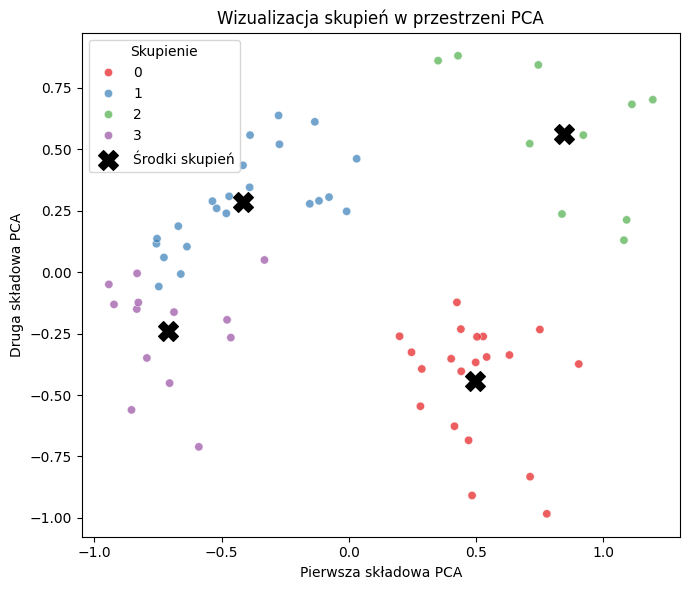

In [41]:
from sklearn.decomposition import PCA

def visualize_clusters(df, predictors, cluster_col):
    """
    Wizualizuje skupienia w 2D przy użyciu PCA lub t-SNE.

    Parametry:
    - df: DataFrame zawierający dane,
    - predictors: lista kolumn używanych do redukcji wymiarów,
    - cluster_col: nazwa kolumny zawierającej przypisane skupienia,
    """

    # Redukcja wymiarów
    reducer = PCA(n_components=2)
    x_label = "Pierwsza składowa PCA"
    y_label = "Druga składowa PCA"
    title = "Wizualizacja skupień w przestrzeni PCA"

    # Przekształcenie danych
    X_transformed = reducer.fit_transform(df[predictors])

    # Utworzenie pomocniczej ramki do wykresu
    df_transformed = df.copy()
    df_transformed['X1'] = X_transformed[:, 0]
    df_transformed['X2'] = X_transformed[:, 1]

    # Tworzenie wykresu
    plt.figure(figsize=(7, 6))

    sns.scatterplot(
        x='X1',
        y='X2',
        hue=cluster_col,
        palette='Set1',
        data=df_transformed,
        alpha=0.7
    )

    # Centroidy pokazujemy tylko dla PCA
    centroids = df_transformed.groupby(cluster_col)[['X1', 'X2']].mean()

    plt.scatter(
        centroids['X1'],
        centroids['X2'],
        marker="X",
        s=200,
        c="black",
        label="Środki skupień"
    )

    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend(title="Skupienie")
    plt.tight_layout()
    plt.show()

visualize_clusters(scaled_food_df, predictors, 'predicted_class')

### Analiza otrzymanych skupień

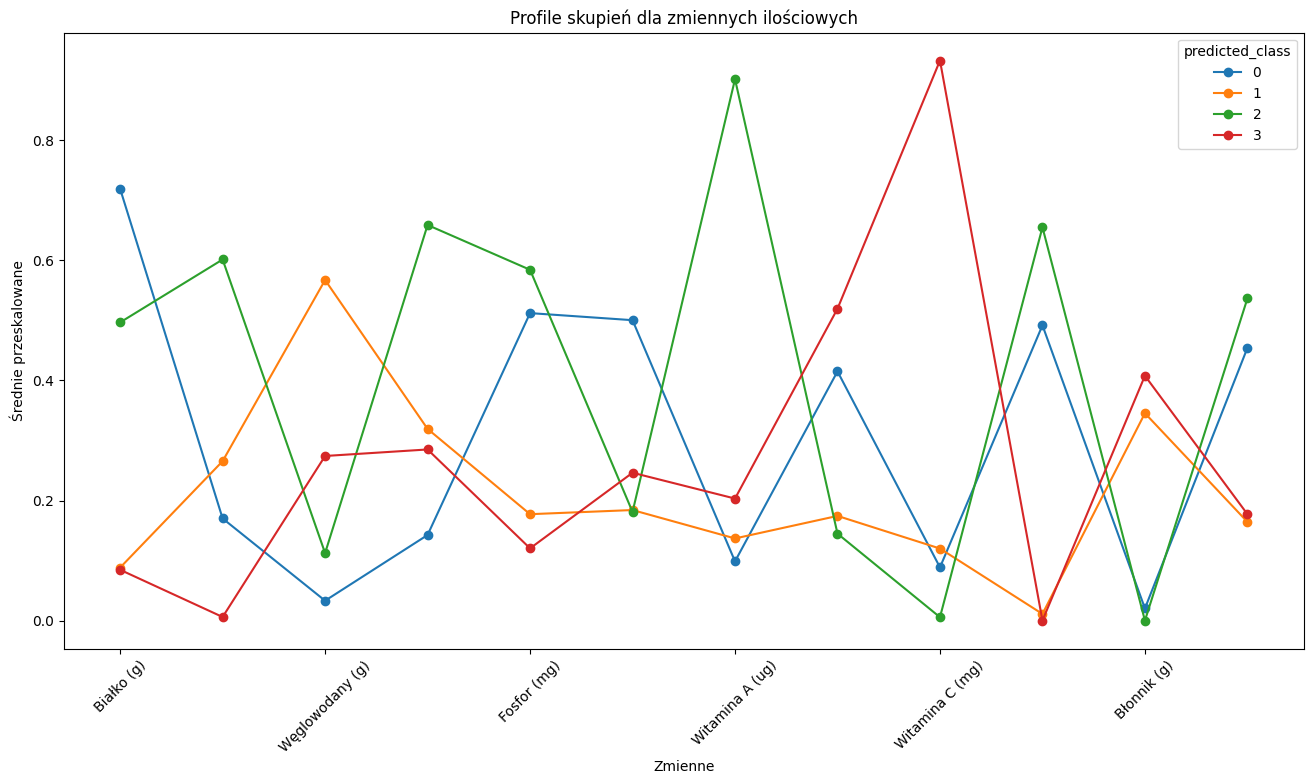

In [42]:
means_scaled = scaled_food_df.groupby("predicted_class")[predictors].mean()

means_scaled.T.plot(figsize=(16, 8), marker="o", linestyle="-")

plt.xlabel("Zmienne")
plt.ylabel("Średnie przeskalowane")
plt.xticks(rotation=45)
plt.title("Profile skupień dla zmiennych ilościowych")

plt.show()

In [43]:
means_scaled 

,Białko (g),Tłuszcz (g),Węglowodany (g),Wapń (mg),Fosfor (mg),Żelazo (mg),Witamina A (ug),Witamina B1 (mg),Witamina C (mg),Witamina D (ug),Błonnik (g),Witamina B2 (mg)
predicted_class,,,,,,,,,,,,
0,0.719140,0.170080,0.033060,0.142506,0.512176,0.500393,0.098605,0.415079,0.088611,0.491854,0.020177,0.454223
1,0.088243,0.265537,0.567307,0.319272,0.177195,0.184103,0.136786,0.174314,0.119949,0.010995,0.345409,0.164303
2,0.496722,0.601490,0.112404,0.658955,0.584335,0.180952,0.901860,0.144770,0.005556,0.655177,0.000000,0.536531
3,0.084549,0.005923,0.274164,0.285017,0.120268,0.246235,0.203220,0.519472,0.932906,0.000000,0.407793,0.177237


In [44]:
for i in range(4):
    print(f"\nProdukty w skupieniu {i}: ")
    # Wyświetlamy nazwy (indeksy) produktów przypisanych do danego skupienia
    print(food_df[food_df['predicted_class'] == i].index.tolist())


Produkty w skupieniu 0: 
['Codfish', 'Perch', 'Salmon', 'Tuna', 'Mussel', 'Octopus', 'Oyster', 'Crab', 'Lobster', 'Trout', 'Ttilapia', 'Lamb', 'Veal', 'Game meat', 'Chicken', 'Duck', 'Goose', 'Turkey', 'Beef', 'Pork']

Produkty w skupieniu 1: 
['Cream', 'Milk', 'Yogurt', 'Olive', 'Apples', 'Blackberries', 'Blueberries', 'Cherries', 'Olives', 'Pears', 'Carrots', 'Onions', 'Potatoes', 'NESTLE, BUTTERFINGER Bar', 'Caramels', 'Fudge', "M & M's", 'MOUNDS Candy Bar', 'NESTLE, 100 GRAND Bar', 'HERSHEY, KIT KAT BIG KAT Bar', 'Vanilla ice cream', 'Chocolate']

Produkty w skupieniu 2: 
['Butter', 'Cheese, cheddar', 'Cheese, cream', 'Cheese, feta', 'Mozzarella', 'Parmesan', 'Egg', 'Margarine', 'Herring', 'Mackerel']

Produkty w skupieniu 3: 
['Grapefruit', 'Kiwifruit', 'Lemon juice', 'Lime juice', 'Oranges', 'Asparagus', 'Beans', 'Broccoli', 'Brussels sprouts', 'Garlic', 'Peas', 'Spinach', 'Tomatoes']


### Charakterystyki skupień
- Skupienie 0 charakteryzuje się wysoką zawartością białka, prawie znikomą zawartością węglowodanów, błonnika. Do tej grupy zaliczają się ryby i mięso.
- Skupienie 1 charakteryzuje się dosyć niską zawartością niałka, dużą węglowodanów. Są to głownie produkty z dużą zawartością cukru: mleko, jogurty, słodkie owoce i słodycze.
- Skupienie 2 charakteryzuje się dużą zawartością białka (ale niższą niż skupienie 0), bardzo wysoką zawartością tłuszczy, niską węglowodanów. Mają też najwięcej wapnia. To skupienie obejmuje głownie nabiał: sery, masło, jajka.
- Skupienie 4 charakteryzuje się niską zawartością białka i tłuszczy, umiarkowaną zawartośćią węglowodanów i bardzo wysoką zawartością witaminy C i błonnika. Są to głowni cytrusy i warzywa.

### Komentarz końcowy
Wybrano metodę K-means. Po przeanalizowaniu różnych liczb skupień zdecydowano się na 4 skupienia, ponieważ pomimo nienajwyższego wskaźnika sylwetki (0.275), rozdzielają produkty w logiczne i sensowne grupy.

# Zadanie 4 - Analiza skupień po redukcji wymiarów

W przygotowanym notebooku jedna z decyzji analitycznych polegała na usunięciu zmiennej `Energia (kcal)`, ponieważ była silnie powiązana z innymi zmiennymi, zwłaszcza z zawartością tłuszczu.

W tym zadaniu sprawdzisz inne podejście: zamiast ręcznie usuwać silnie powiązane zmienne, zastosujesz redukcję wymiarów, a następnie wykonasz analizę skupień na uzyskanych składowych lub czynnikach.

## Co należy zrobić?

1. Przygotuj dane liczbowe do analizy.
2. Nie usuwaj zmiennej `Energia (kcal)` na podstawie samej korelacji.
3. Sprawdź, czy struktura korelacji między zmiennymi uzasadnia zastosowanie redukcji wymiarów:
   - oblicz miarę KMO,
   - wykonaj test sferyczności Bartletta.
4. Wykonaj PCA.
5. Wybierz liczbę składowych na podstawie:
   - wartości własnych,
   - procentu wyjaśnionej wariancji,
   - wykresu osypiska,
   - interpretowalności składowych.
6. Zapisz wartości składowych dla obserwacji.
7. Wykonaj analizę skupień na uzyskanych składowych.
8. Porównaj wyniki z analizą skupień wykonaną na oryginalnych zmiennych.

## Co należy porównać?

Porównaj oba podejścia pod względem:

- liczby i liczności skupień,
- wartości wskaźnika sylwetki,
- wartości Calinski-Harabasz Score,
- wartości Davies-Bouldin Score,
- interpretowalności profili skupień,
- zgodności lub podobieństwa uzyskanych podziałów.

Do porównania dwóch różnych podziałów możesz wykorzystać Adjusted Rand Index, traktując jeden model jako punkt odniesienia.

## Pytania do interpretacji

1. Czy KMO i test Bartletta sugerują, że redukcja wymiarów ma sens?
2. Ile składowych lub czynników warto zachować?
3. Jak można zinterpretować uzyskane składowe/czynniki?
4. Czy analiza skupień na skorach daje bardziej czytelne grupy niż analiza na oryginalnych zmiennych?
5. Czy wyniki obu podejść są podobne?
6. Które podejście jest lepsze: analiza na oryginalnych zmiennych czy analiza po redukcji wymiarów?
7. Czy usunięcie zmiennej `Energia (kcal)` było konieczne, czy redukcja wymiarów lepiej rozwiązuje problem współzależności zmiennych?

## Uwaga metodyczna

KMO i test Bartletta służą do oceny, czy dane mają strukturę korelacyjną, która uzasadnia zastosowanie analizy PCA lub podobnych metod redukcji wymiarów.

Dopiero po redukcji wymiarów wykonujemy analizę skupień i oceniamy jej jakość za pomocą miar typowych dla segmentacji.

In [45]:
# skalowanie danych przed PCA
from sklearn.preprocessing import StandardScaler
predictors = [var for var in food_df.columns if var not in ['ID', 'predicted_class']]

scaler = StandardScaler()
scaled_food_data = scaler.fit_transform(food_df[predictors])
scaled_food_df = pd.DataFrame(scaled_food_data, columns=predictors, index=food_df.index)
scaled_food_df.head()


,Energia (kcal),Białko (g),Tłuszcz (g),Węglowodany (g),Wapń (mg),Fosfor (mg),Żelazo (mg),Witamina A (ug),Witamina B1 (mg),Witamina C (mg),Witamina D (ug),Błonnik (g),Witamina B2 (mg)
Butter,2.260763,-0.954081,2.723963,-0.826265,-0.568751,-0.246994,-0.961120,2.141652,-1.093224,-0.696905,1.116774,-0.782372,-0.946583
"Cheese, cheddar",1.229238,1.311562,1.834811,-0.568853,2.276293,2.596089,-0.857114,2.141652,-0.742358,-0.696905,0.398419,-0.782372,2.000565
"Cheese, cream",0.908187,-0.408763,1.925779,-0.362413,0.876395,-0.302836,-0.883116,2.141652,-0.830074,-0.696905,2.056858,-0.782372,0.519511
"Cheese, feta",0.396884,0.420532,0.866363,-0.483898,2.276293,1.895854,-0.415088,0.936625,1.085071,-0.696905,0.029877,-0.782372,2.516690
Mozzarella,0.610918,1.239538,0.952501,-0.645312,2.276293,2.058366,-0.597099,1.659641,-0.727738,-0.696905,0.029877,-0.782372,0.915955


### KMO i test Bartletta

In [46]:
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo
# Test sferyczności Bartletta
chi_square_value, p_value = calculate_bartlett_sphericity(scaled_food_df)
print(f"Test Bartletta - Statystyka Chi-kwadrat: {chi_square_value:.2f}")
print(f"Test Bartletta - p-value: {p_value:.4f}")

# Test KMO
kmo_all, kmo_model = calculate_kmo(scaled_food_df)
print(f"Współczynnik KMO: {kmo_model:.3f}")

Test Bartletta - Statystyka Chi-kwadrat: 610.29
Test Bartletta - p-value: 0.0000
Współczynnik KMO: 0.584


Dane są wystarczająco skorelowane by przeprowadzić analizę PCA - współczynnik KMO jest powyżej 0.5 (0.584), jak również p-value z testu Bartletta jest mniejsze niż 0.05.

### Dobór liczby składowych głownych

In [47]:
from sklearn.decomposition import PCA

# Inicjalizacja PCA dla wszystkich zmiennych
pca = PCA(random_state=seed)
pca.fit(scaled_food_df)

# Obliczenie wartości własnych
eigenvalues = pca.explained_variance_
# Procent wyjaśnionej wariancji
variance_ratio = pca.explained_variance_ratio_
# Skumulowany procent wyjaśnionej wariancji
cum_variance_ratio = np.cumsum(variance_ratio)

In [48]:
pca_stats = pd.DataFrame({
    'Składowa': range(1, len(eigenvalues) + 1),
    'Wartość własna': eigenvalues,
    '% Wariancji': variance_ratio * 100,
    '% Skumulowany': cum_variance_ratio * 100
})
print(pca_stats.round(2).to_string(index=False))

 Składowa  Wartość własna  % Wariancji  % Skumulowany
        1            4.39        33.25          33.25
        2            2.57        19.43          52.68
        3            1.70        12.84          65.52
        4            1.34        10.13          75.64
        5            0.84         6.39          82.03
        6            0.72         5.44          87.47
        7            0.47         3.54          91.01
        8            0.42         3.15          94.16
        9            0.33         2.51          96.67
       10            0.22         1.64          98.31
       11            0.13         0.97          99.28
       12            0.08         0.59          99.86
       13            0.02         0.14         100.00


Opisywana zmienność:  [0.33245514 0.19430532 0.12839221 0.10125983 0.06390005 0.05439806
 0.0354126  0.03151352 0.02506698 0.01638131 0.00970616 0.00585021
 0.00135861]


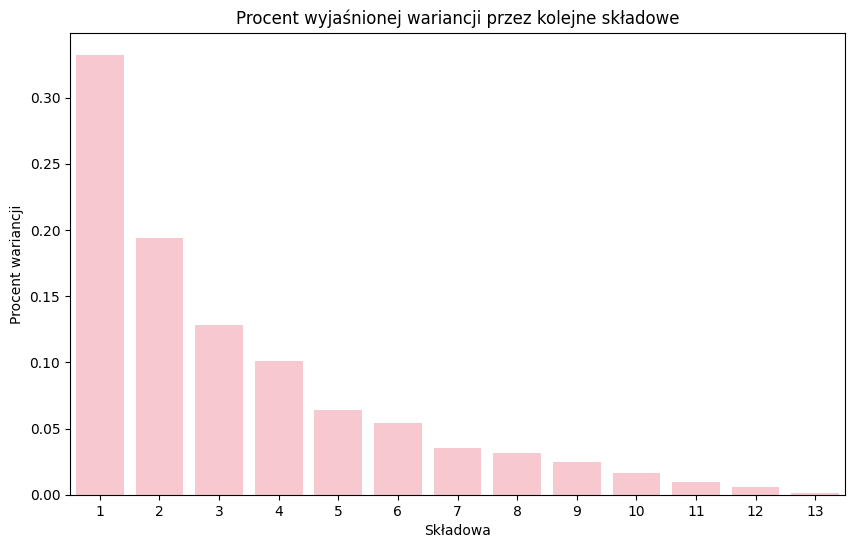

In [49]:
print('Opisywana zmienność: ', variance_ratio)

plt.figure(figsize=(10, 6))
sns.barplot(x=np.arange(1,14), y=variance_ratio, color='pink')
plt.title("Procent wyjaśnionej wariancji przez kolejne składowe")
plt.xlabel("Składowa")
plt.ylabel("Procent wariancji")
plt.show()

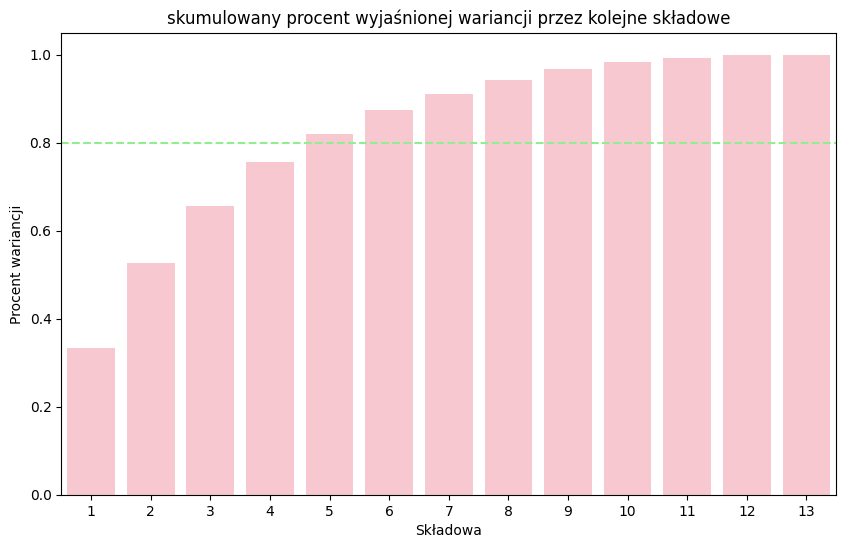

In [50]:
plt.figure(figsize=(10, 6))
sns.barplot(x=np.arange(1,14), y=cum_variance_ratio, color='pink')
plt.axhline(y=0.80, color='lightgreen', linestyle='--', label='80% wyjaśnionej wariancji')
plt.title("skumulowany procent wyjaśnionej wariancji przez kolejne składowe")
plt.xlabel("Składowa")
plt.ylabel("Procent wariancji")
plt.show()

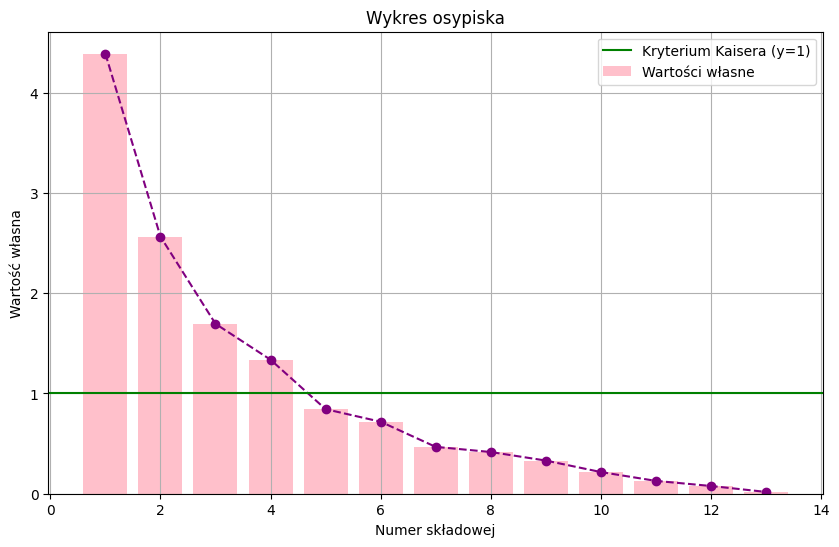

In [51]:
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(eigenvalues) + 1), eigenvalues, color='pink', label='Wartości własne')
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o', color='purple', linestyle='--')
plt.axhline(y=1, color='green', linestyle='-', label='Kryterium Kaisera (y=1)')
plt.title('Wykres osypiska')
plt.xlabel('Numer składowej')
plt.ylabel('Wartość własna')
plt.legend()
plt.grid(True)
plt.show()

Wybrano 5 głownych składowych, dlatego że wyjaśniają ponad 80% danych, a na wykresie osypiska widać że po 5 składowej wykres się wypłaszcza.

### PCA - 5 głownych składowych

In [52]:
pca_final = PCA(n_components=5, random_state=seed)
food_pca_data = pca_final.fit_transform(scaled_food_df)

pca_cols = [f'PC{i+1}' for i in range(5)]
food_pca_df = pd.DataFrame(food_pca_data, columns=pca_cols, index=scaled_food_df.index)
food_pca_df.head()

,PC1,PC2,PC3,PC4,PC5
Butter,1.624928,3.182537,-1.912993,-0.552351,-2.555702
"Cheese, cheddar",4.517903,1.660059,-0.419152,2.000763,0.881955
"Cheese, cream",2.269883,2.063805,-1.891397,0.854854,-1.421381
"Cheese, feta",3.274970,0.176728,0.787611,2.071480,1.139328
Mozzarella,3.343984,1.062003,-0.665671,1.734214,1.164700


,PC1,PC2,PC3,PC4,PC5
Energia (kcal),0.219925,0.479069,0.247593,-0.169712,-0.186572
Białko (g),0.379369,-0.273751,0.064007,-0.116757,0.208813
Tłuszcz (g),0.259744,0.441480,0.114915,-0.080797,-0.318765
Węglowodany (g),-0.188802,0.388421,0.365635,0.007085,0.226934
Wapń (mg),0.168426,0.208197,0.014228,0.638853,0.408029
Fosfor (mg),0.426738,-0.074173,0.126134,0.062773,0.214466
Żelazo (mg),0.128930,-0.219923,0.498475,0.003927,-0.365442
Witamina A (ug),0.210067,0.194725,-0.275055,0.532026,-0.397962
Witamina B1 (mg),-0.018601,-0.341448,0.454943,0.181644,-0.236256
Witamina C (mg),-0.318458,-0.211030,0.007908,0.407373,-0.185238


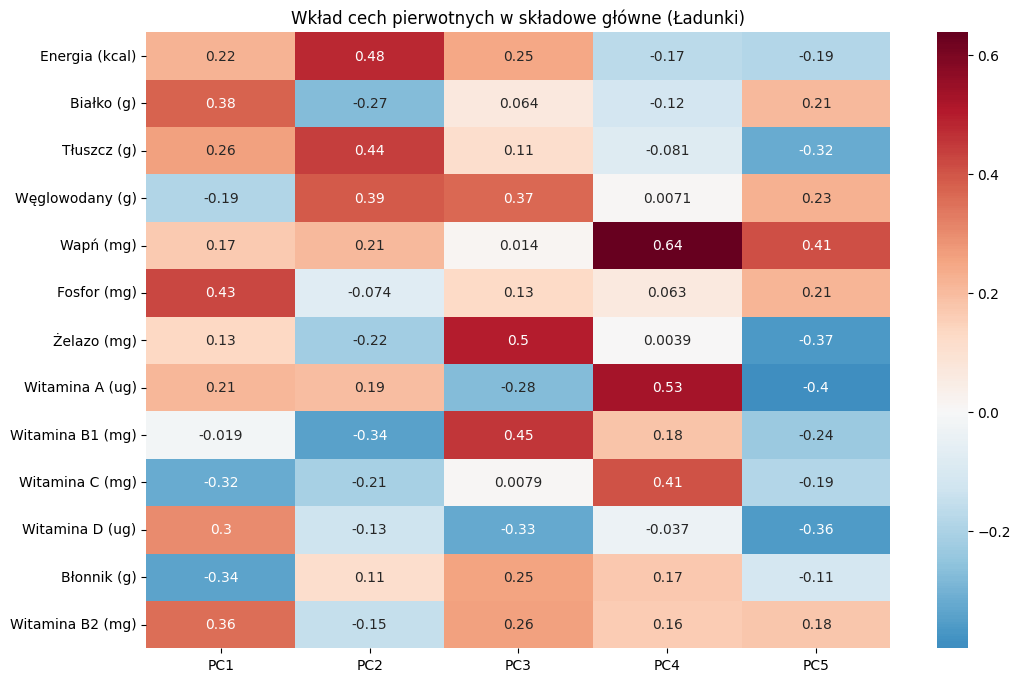

In [53]:
loadings = pd.DataFrame(
    pca_final.components_.T,
    columns=pca_cols,
    index=predictors
)

display(loadings)

plt.figure(figsize=(12, 8))
sns.heatmap(loadings, annot=True, cmap='RdBu_r', center=0)
plt.title('Wkład cech pierwotnych w składowe główne (Ładunki)')
plt.show()

Interpretacja głownych składowych:
- PC1: Największy wkład dodatni: białko, fosfor, B2. Największy wkład ujemny: witamina C, błonnik. Produkty o wysokich wartościach PC1 to mięsa i ryby (bogate w białko i fosfor, brak błonnika i witaminy C). Produkty o niskich wartościach PC1 to warzywa i owoce.
- PC2: Największe wkład dodatni: energia, tłuszcz, węglowodany. Wysokie wartości PC2 wskazują na produkty wysokoenergetyczne
- PC3: Największe wkład dodatni: żelazo, witamina B1. Największy wkład ujemny: witamina A, witamina D. PC3 pomaga wyłonić produkty bogate w żelazo, które niekoniecznie są tłuste czy bogate w witaminy rozpuszczalne w tłuszczach (A, D).
- PC4: Największe wkład dodatni: wapń, witamina A, witamina C. Wysokie PC4 wskaże na produkty o wyjątkowo wysokiej zawartości konkretnych minerałów i witamin.
- PC5: Największe wkład dodatni: wapń, węglowodany. Największy wkład ujemny: witamina A, żelazo, witamina D, tłuszcz. PC5 pomaga odróżnić chudy nabiał (wysoki wapń, niski tłuszcz i wit. A/D) od tłustych serów czy mięs.

### Analiza skupień

In [54]:
n_clusters = 4

# Budowa modelu KMeans
kmeans_model = KMeans(
    n_clusters=n_clusters,
    random_state=seed,
    n_init=10
)
kmeans_model_classes = kmeans_model.fit_predict(scaled_food_df[predictors])

food_df['predicted_class_pca'] = kmeans_model_classes
scaled_food_df['predicted_class_pca'] = kmeans_model_classes

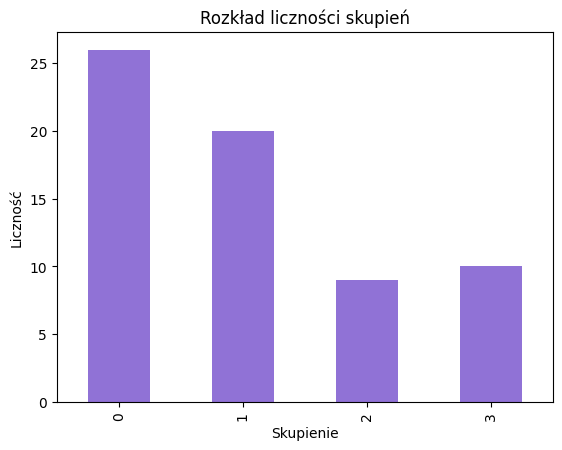

In [55]:
food_df["predicted_class_pca"].value_counts().sort_index().plot(kind="bar", color = "#9072d6")

plt.xlabel("Skupienie")
plt.ylabel("Liczność")
plt.title("Rozkład liczności skupień")

plt.show()

In [56]:
# wzkaźnik sylwetki
silhouette_avg_agglomerative = silhouette_score(
    scaled_food_df[predictors],
    scaled_food_df["predicted_class_pca"]
)

print(f"Wartość wskaźnika sylwetki: {silhouette_avg_agglomerative:.4f}")

# Calinski-Harabasz
calinski_harabasz_agglomerative = calinski_harabasz_score(
    scaled_food_df[predictors],
    scaled_food_df["predicted_class_pca"]
)
print(f"Wartość wskaźnika Calinski-Harabasz: {calinski_harabasz_agglomerative:.4f}")

# Davies-Bouldin
davies_bouldin_agglomerative = davies_bouldin_score(
    scaled_food_df[predictors],
    scaled_food_df["predicted_class_pca"]
)
print(f"Wartość wskaźnika Davies-Bouldin: {davies_bouldin_agglomerative:.4f}")

Wartość wskaźnika sylwetki: 0.3048
Wartość wskaźnika Calinski-Harabasz: 21.3645
Wartość wskaźnika Davies-Bouldin: 1.2547


### Porównanie otrzymanych klastrów

In [61]:
for i in range(4):
    print(f"\nProdukty w skupieniu {i}: ")
    # Wyświetlamy nazwy (indeksy) produktów przypisanych do danego skupienia
    print(scaled_food_df[scaled_food_df['predicted_class_pca'] == i].index.tolist())


Produkty w skupieniu 0: 
['Cream', 'Milk', 'Yogurt', 'Apples', 'Blackberries', 'Blueberries', 'Cherries', 'Grapefruit', 'Kiwifruit', 'Lemon juice', 'Lime juice', 'Olives', 'Oranges', 'Pears', 'Asparagus', 'Beans', 'Broccoli', 'Brussels sprouts', 'Carrots', 'Garlic', 'Onions', 'Peas', 'Potatoes', 'Spinach', 'Tomatoes', 'Vanilla ice cream']

Produkty w skupieniu 1: 
['Codfish', 'Perch', 'Salmon', 'Tuna', 'Mussel', 'Octopus', 'Oyster', 'Crab', 'Lobster', 'Trout', 'Ttilapia', 'Lamb', 'Veal', 'Game meat', 'Chicken', 'Duck', 'Goose', 'Turkey', 'Beef', 'Pork']

Produkty w skupieniu 2: 
['Olive', 'NESTLE, BUTTERFINGER Bar', 'Caramels', 'Fudge', "M & M's", 'MOUNDS Candy Bar', 'NESTLE, 100 GRAND Bar', 'HERSHEY, KIT KAT BIG KAT Bar', 'Chocolate']

Produkty w skupieniu 3: 
['Butter', 'Cheese, cheddar', 'Cheese, cream', 'Cheese, feta', 'Mozzarella', 'Parmesan', 'Egg', 'Margarine', 'Herring', 'Mackerel']


Na pierwszy rzut oka, otrzymane skupienia wyglądają bardzo podobnie do tych otrzymanych bez PCA. 
- skupienie 0 - lekkie produkty z węglowodanów, a bez tłuszczy - owoce, warzywa, lekkie rzeczy mleczne
- supienie 1 - mięsa i ryby
- skupienie 3 - słodycze 
- skupienie 4 - tłuste produkty mleczne i tłuste ryby

Główna róznica względem wcześniejszych skupień to wspólna grupa warzyw i owoców, a zupełnie osobna słodyczy (gdzie wcześniej, słodycze i słodkie owoce były razem). Ze względu na to uważam, że ten nowy podział jest lepszy.

In [64]:
# porównanie skupień z PCA z oryginalnymi skupieniami
from sklearn.metrics import adjusted_rand_score
ari_score = adjusted_rand_score(food_df['predicted_class'], food_df['predicted_class_pca'])

print(f"Adjusted Rand Index (ARI): {ari_score:.4f}")

Adjusted Rand Index (ARI): 0.6547


ARI 0.65 oznacza że klastry są dosyć podobne i sens grup pozostał ten sam, z czym się faktycznie zgadzam

**Komentarz końcowy:** Podejście oryginalne oraz to z PCA dały podobne wyniki, jednakże uważam że minimalnie bardziej oddająe rzeczywistość są klastry z podejścia z PCA. Eksperyment udowodnił, że usuwanie zmiennej ENergia nie było konieczne, ponieważ PCA rozwiązało ten problem.